# Busy Airports: Predicting TSA Traffic at Major U.S. Airports

**Team members**: [David Friedenberg](https://github.com/friedenberg12), [Agniva Dasgupta](https://github.com/adg1016), [Charuhas Shiveshwarkar](https://github.com/SChars), [Ivan Caro Terrazas](https://github.com/icaromx), [Ahmad Shamloumehr](https://github.com/)

This notebook uses the TSA hourly passenger throughput dataset to build a machine learning workflow for short-term load forecasting.

## Workflow
1. Load and preprocess the dataset

## Pipeline overview

Raw data → Preprocessing → Train/Test Split → Model Training → Evaluation

## Models compared
- SARIMA
- Harmonic Regression
- STL decomposition

The goal is not only to obtain strong predictive performance, but also to keep the pipeline clear, modular, and reproducible.

## Imports

In [2]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# Import custom module from src/ directory
from busy_airports.preprocessing import load_data, retrieve_airport_data

## Data loading and preprocessing

The TSA dataset is loaded and column names are renamed to an easier way to parse them.

In [3]:
tsa_data = load_data("data/tsa-throughput-data-complete.csv")
print('Rows:', len(tsa_data), 'Columns:', tsa_data.shape[1])
mem = tsa_data.memory_usage(deep=True).sum() / (1024**2)
print(f'Memory MB: {mem:.2f}')
display(tsa_data.head(3))
display(tsa_data.tail(3))
display(tsa_data.describe(include='all').T)

Rows: 11054590 Columns: 10
Memory MB: 1658.81


,datetime,airport_code,airport_name,city,state,checkpoint,total_passenger_throughput,date,month,week
0,2022-01-01,ANC,Ted Stevens Anchorage International,Anchorage,AK,South Checkpoint,62,2022-01-01,1,52
1,2022-01-01,ATL,Hartsfield Atlanta International,Atlanta,GA,Main Checkpoint,17,2022-01-01,1,52
2,2022-01-01,BFL,"Meadows Field, Bakersfield",Bakersfield,CA,BFL01,0,2022-01-01,1,52


,datetime,airport_code,airport_name,city,state,checkpoint,total_passenger_throughput,date,month,week
11054587,2025-12-31 23:00:00,SMF,Sacramento International,Sacramento,CA,Central B,23,2025-12-31,12,1
11054588,2025-12-31 23:00:00,SMF,Sacramento International,Sacramento,CA,Terminal A,106,2025-12-31,12,1
11054589,2025-12-31 23:00:00,TPA,Tampa International,Tampa,FL,TPA A,28,2025-12-31,12,1


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
datetime,11054590,NaN,NaN,NaN,2024-01-07 05:16:40.525789,2022-01-01 00:00:00,2023-01-07 05:00:00,2024-01-09 19:00:00,2025-01-07 10:00:00,2025-12-31 23:00:00,NaN
airport_code,11054590,434,DFW,385638,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airport_name,11054590,688,Los Angeles International,317481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,11054590,422,Chicago,403015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,11054590,55,CA,1240223,NaN,NaN,NaN,NaN,NaN,NaN,NaN
checkpoint,11054590,544,Main Checkpoint,372359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_passenger_throughput,11054590.0,NaN,NaN,NaN,300.817651,0.0,49.0,173.0,416.0,4405.0,370.153141
date,11054590,1461,2025-07-10,8190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,11054590.0,NaN,NaN,NaN,6.53834,1.0,4.0,7.0,10.0,12.0,3.430813
week,11054590.0,NaN,NaN,NaN,26.544966,1.0,14.0,27.0,39.0,52.0,14.980496


Before working further with this dataset, we remove the holdout data until the very end

In [4]:
tsa_data = tsa_data[tsa_data['datetime'] <= '2025-06-30']

# Exploratory Data Analysis

## Time Series Plots

In [5]:
from busy_airports.eda import plot_airport_data

We start by plotting the airport data for a particular checkpoint in Chicago International Airport

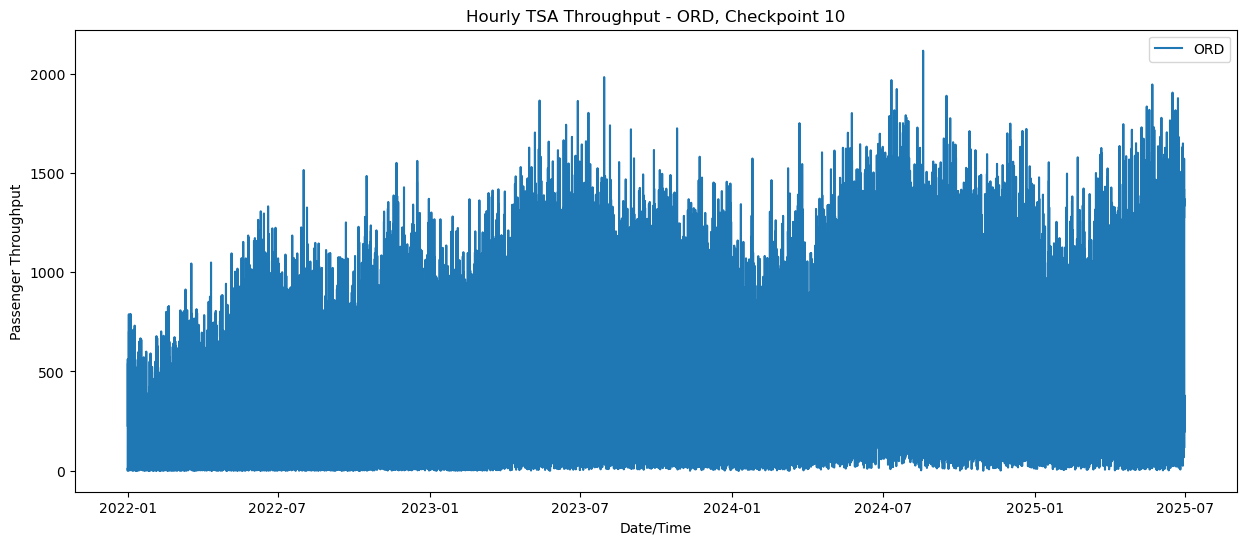

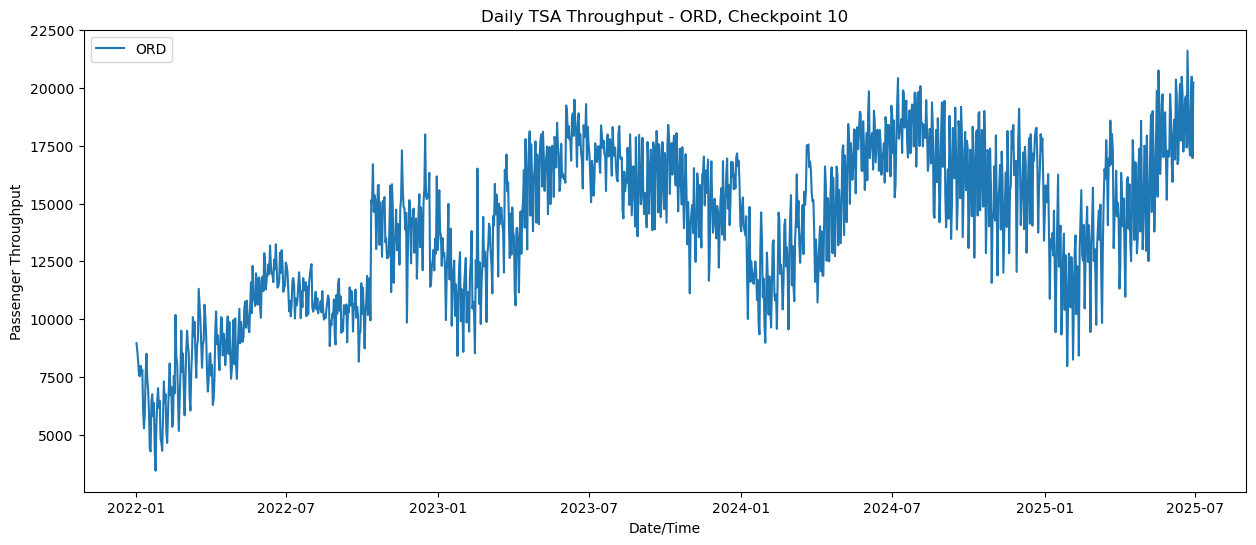

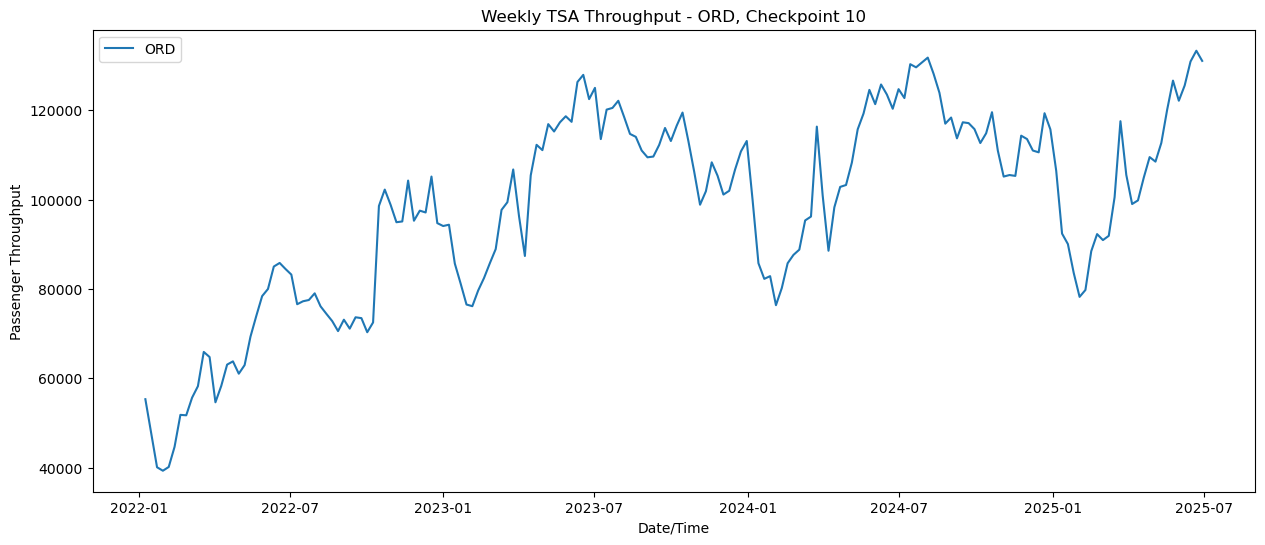

In [6]:
plot_airport_data(tsa_data, airport='ORD', frequency='H', checkpoint='10')
plot_airport_data(tsa_data, airport='ORD', frequency='D', checkpoint='10')
plot_airport_data(tsa_data, airport='ORD', frequency='W', checkpoint='10')

There are a few useful observations to make about this dataset. First of all, notice that the hourly data appears to be less useful than the daily and weekly data. Also notice that it is hard to observe a trend for the data from a single checkpoint, since this checkpoint may only be opened and closed during certain hours.

Next we can look at the airport as a whole:

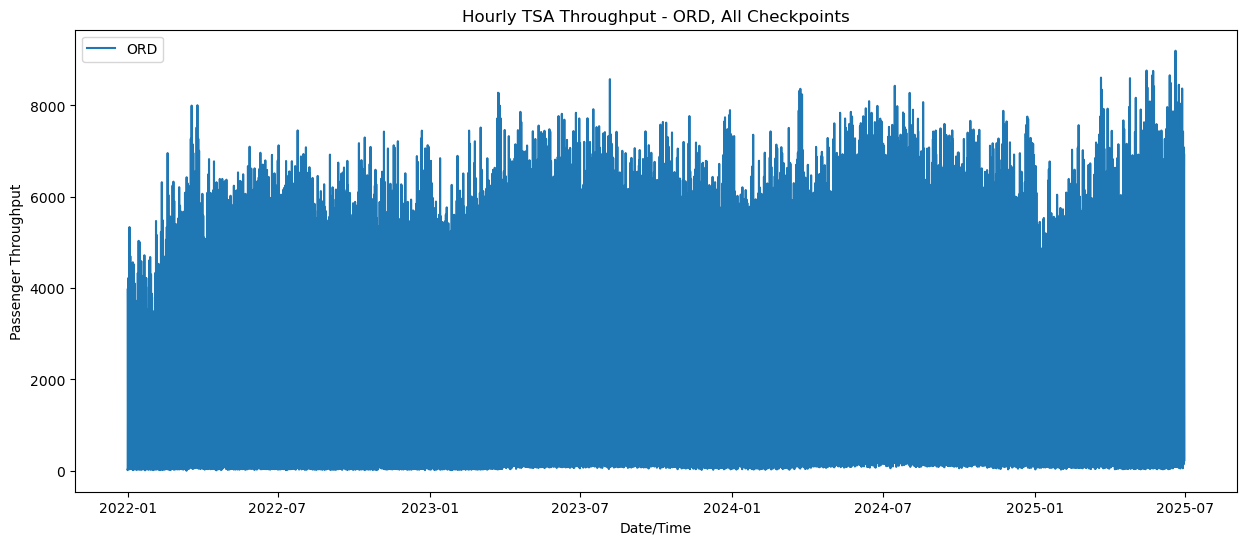

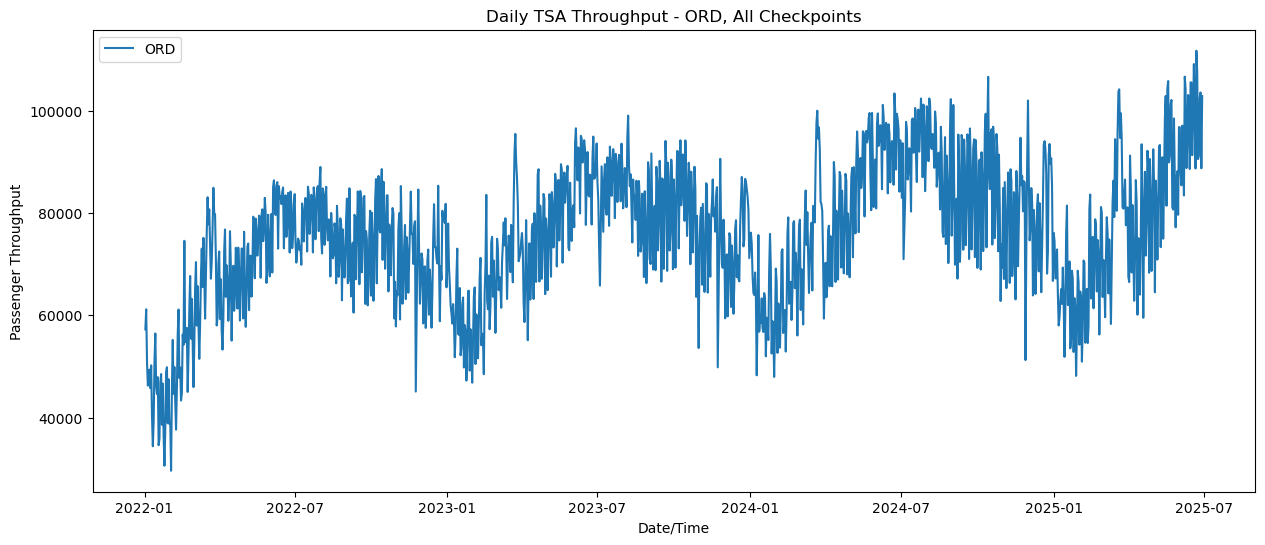

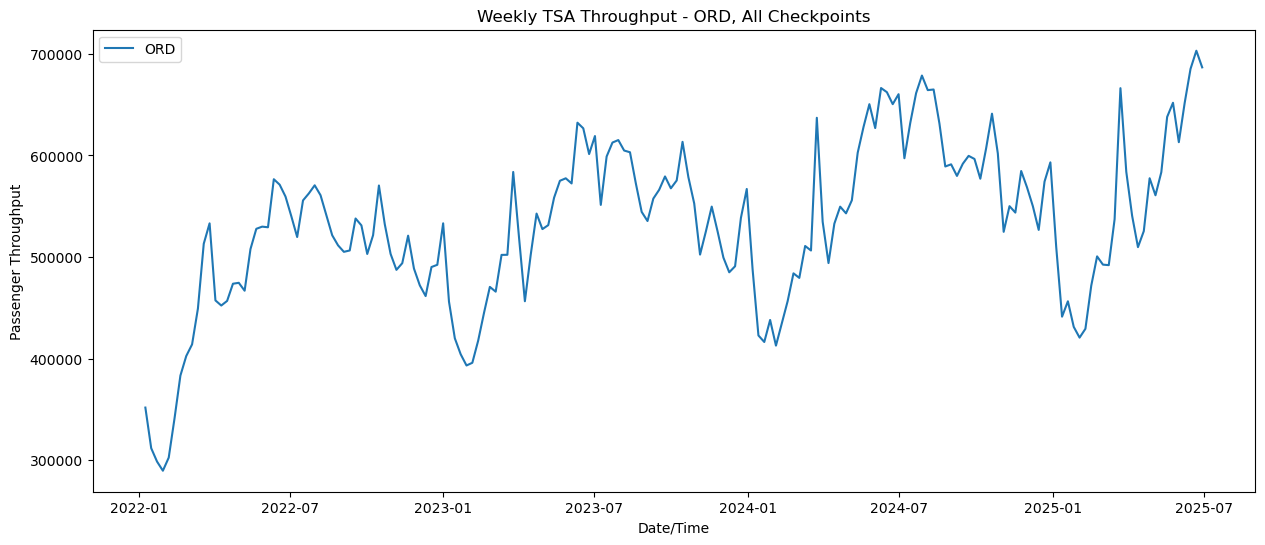

In [7]:
plot_airport_data(tsa_data, airport='ORD', frequency='H')
plot_airport_data(tsa_data, airport='ORD', frequency='D')
plot_airport_data(tsa_data, airport='ORD', frequency='W')

These plots clearly show that when considering all of the checkpoints, the throughput in an airport clearly shows annual seasonality and a linear trend. This can be further confirmed by looking at the autocorrelation and partial autocorrelation functions for the daily and weekly data.

We can also compare across multiple airports to verify that they carry the same trends.

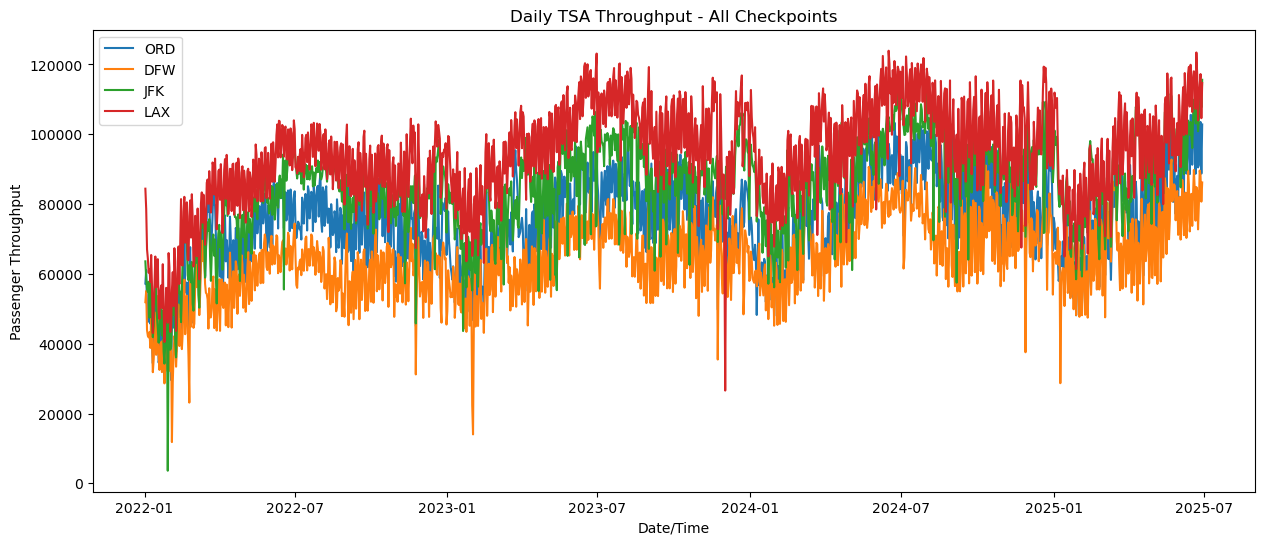

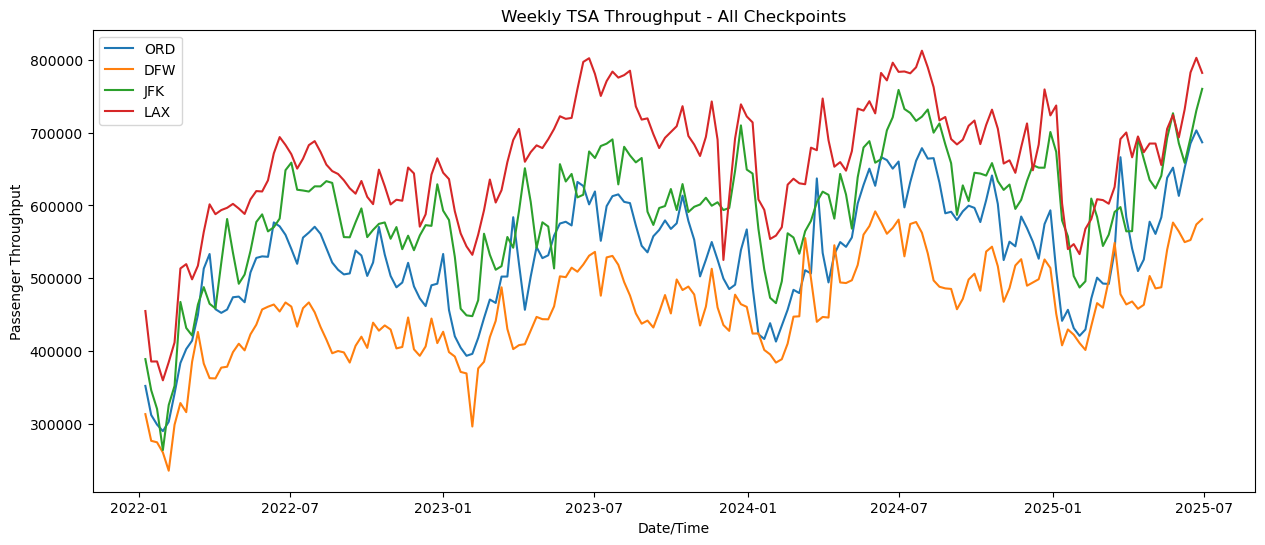

In [8]:
plot_airport_data(tsa_data, airport=['ORD','DFW','JFK','LAX'], frequency='D')
plot_airport_data(tsa_data, airport=['ORD','DFW','JFK','LAX'], frequency='W')

## ACF and PACF Plots

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [10]:
ord_daily = retrieve_airport_data(tsa_data, airport="ORD", frequency="D")
ord_weekly = retrieve_airport_data(tsa_data, airport="ORD", frequency="W")

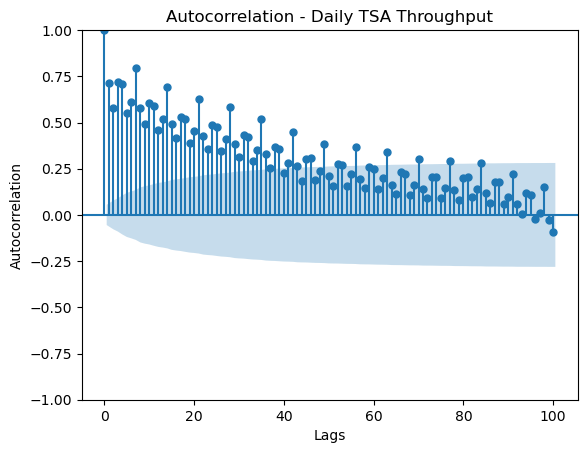

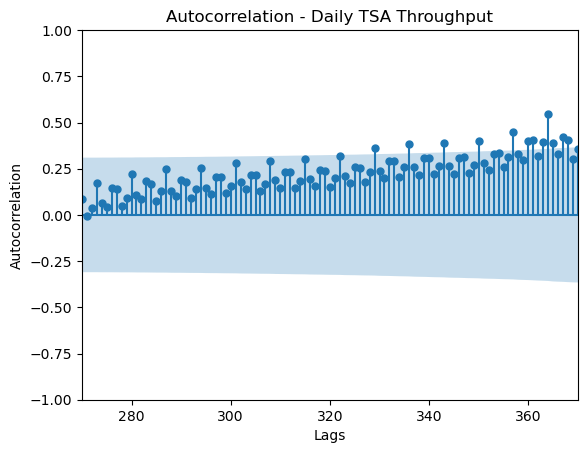

In [11]:
plot_acf(ord_daily.total_passenger_throughput, lags=100)
plt.title("Autocorrelation - Daily TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()
plot_acf(ord_daily.total_passenger_throughput, lags=370)
plt.title("Autocorrelation - Daily TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.xlim(270,370)
plt.show()

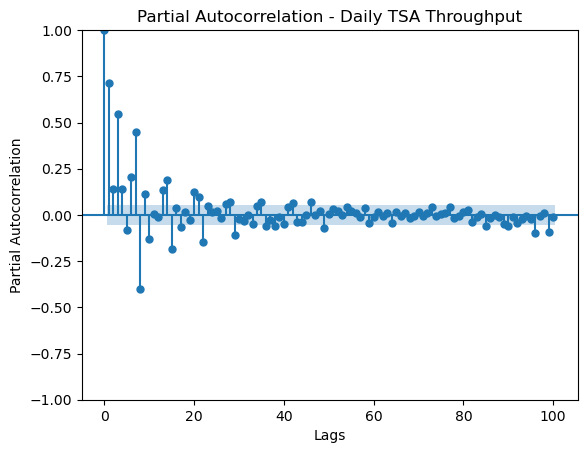

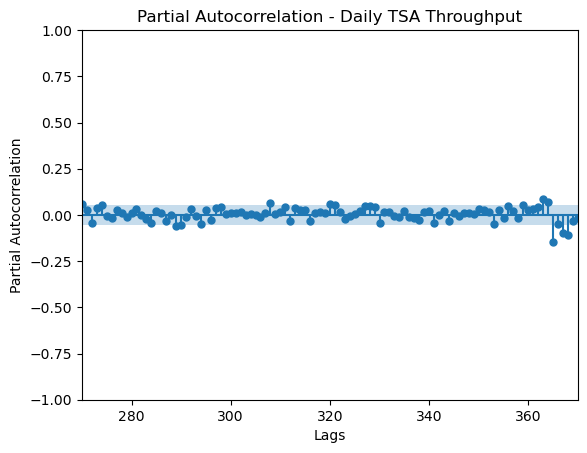

In [12]:
plot_pacf(ord_daily.total_passenger_throughput, lags=100)
plt.title("Partial Autocorrelation - Daily TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()
plot_pacf(ord_daily.total_passenger_throughput, lags=370)
plt.title("Partial Autocorrelation - Daily TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.xlim(270,370)
plt.show()

Here note from the autocorrelation that there is a large spike at every 7 lags and another large spike after 365 lags. This indicates both a weekly and annual seasonality in the daily data.

We can also look at the ACF and PACF for the weekly data.

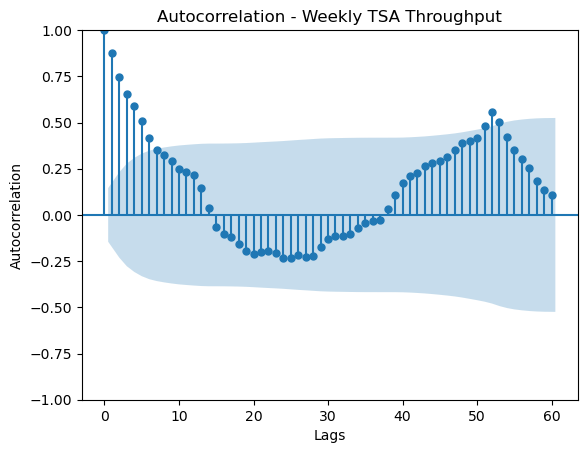

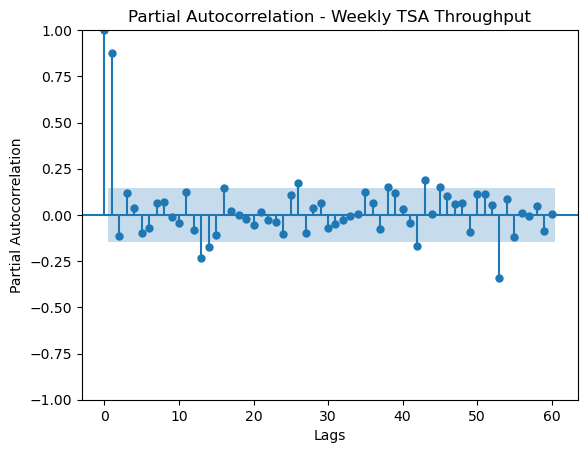

In [13]:
plot_acf(ord_weekly.total_passenger_throughput, lags=60)
plt.title("Autocorrelation - Weekly TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()
plot_pacf(ord_weekly.total_passenger_throughput, lags=60)
plt.title("Partial Autocorrelation - Weekly TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()

Here we observe that the dominant lags are the small lags (below about 5-6) and again there is annual seasonality indicated by a spike at lag 52.

Even though these models are clearly note stationary, we can model the seasonailty using either STL decomposition or SARIMA model, leaving the remaining residuals to be approximately stationary.

## Baseline Models

For our baseline models, we chose to use the Naive Seasonal Model with Drift and the Triple Exponential Smoothing model. These are simple enough models that are able to capture the annual seasonality and overall trend that we see in the throughput data.

In [14]:
from busy_airports.baselines import NaiveSeasonalWithDrift, TripleExponentialSmoothing
from busy_airports.metrics import evaluate_forecast

As a simple test of these models, we will create a train-test split with the last six months of data used to test the baseline models.

In [15]:
# daily train-test split
ord_daily_train = ord_daily[ord_daily['datetime'] < "2025-01-01"]
ord_daily_test  = ord_daily[ord_daily['datetime'] >= "2025-01-01"]
# weekly train-test split
ord_weekly_train = ord_weekly[ord_weekly['datetime'] < "2025-01-01"]
ord_weekly_test  = ord_weekly[ord_weekly['datetime'] >= "2025-01-01"]


Naive Seasonal with Drift:
  MAE: 11,626
  MAPE: 14.64%
  RMSE: 14,035


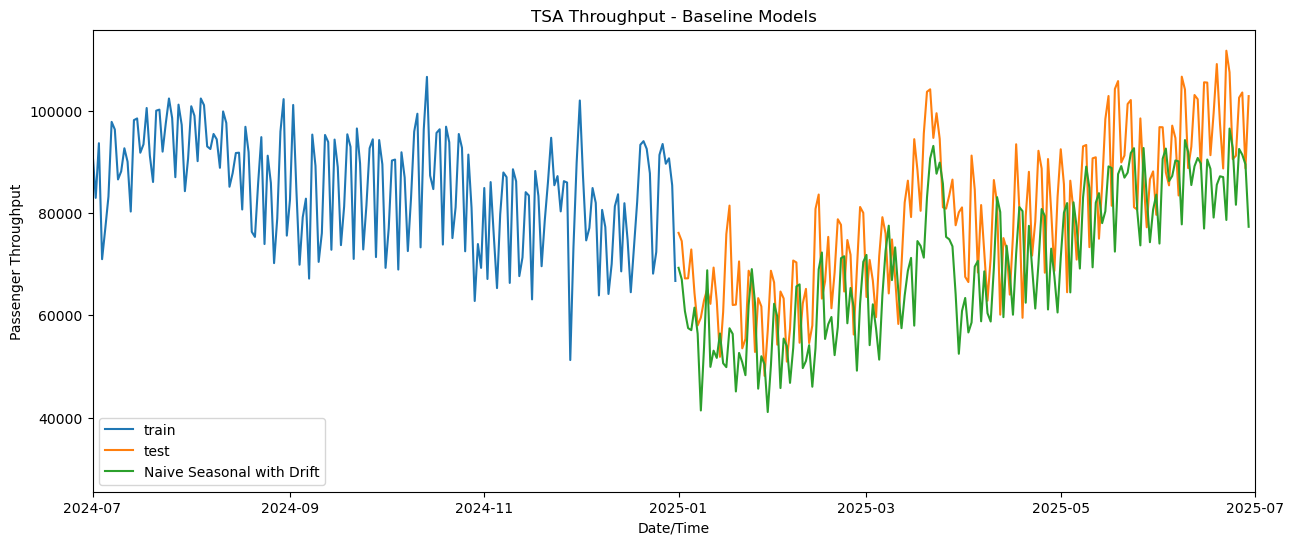

In [16]:
# Apply the Naive Seasonal model with Drift to the daily data and calculate metrics
nswd_model = NaiveSeasonalWithDrift(season_length=365)
nswd_model.fit(ord_daily_train.total_passenger_throughput)
nswd_forecast = nswd_model.forecast(h=len(ord_daily_test))
nswd_metrics = evaluate_forecast(ord_daily_test.total_passenger_throughput,
                                 nswd_forecast,
                                 "Naive Seasonal with Drift")
# Print metrics
print(f"\nNaive Seasonal with Drift:")
print(f"  MAE: {nswd_metrics['mae']:,.0f}")
print(f"  MAPE: {nswd_metrics['mape']*100:.2f}%")
print(f"  RMSE: {nswd_metrics['rmse']:,.0f}")
# Plot results
plt.figure(figsize=(15, 6))
plt.plot(ord_daily_train.datetime, ord_daily_train.total_passenger_throughput, label="train")
plt.plot(ord_daily_test.datetime, ord_daily_test.total_passenger_throughput, label="test")
plt.plot(ord_daily_test.datetime, nswd_forecast, label="Naive Seasonal with Drift")
plt.title("TSA Throughput - Baseline Models")
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.xlim(pd.Timestamp("2024-07-01"), pd.Timestamp("2025-07-01"))
plt.legend()
plt.show()


Triple Exponential Smoothing:
  MAE: 9,070
  MAPE: 12.31%
  RMSE: 11,372


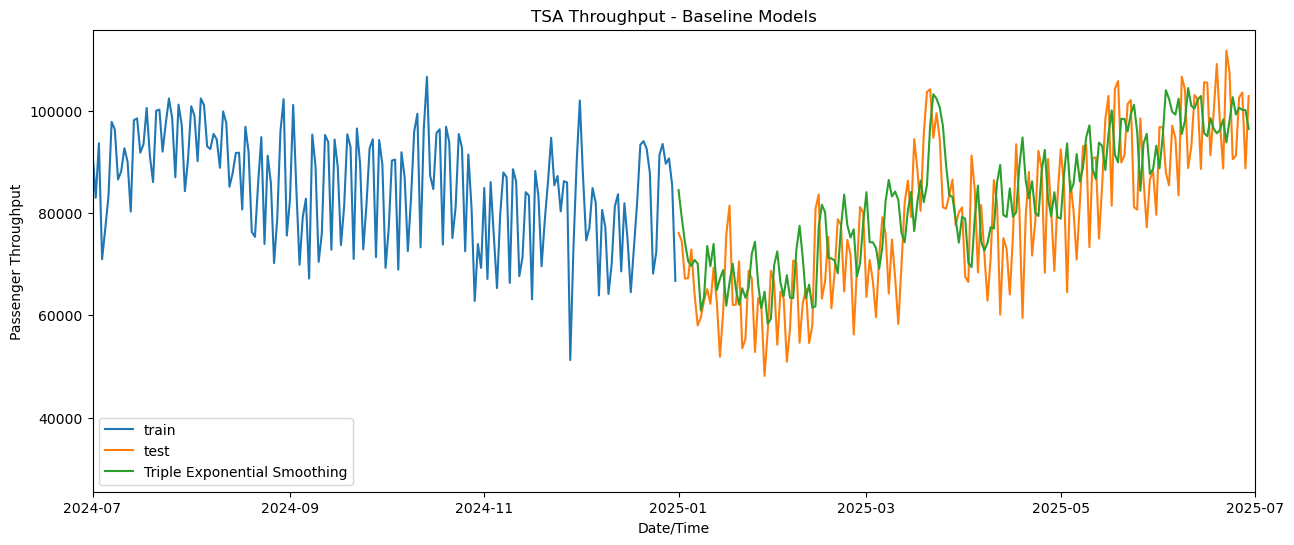

In [17]:
# Apply the Triple Exponential smoothing model to the daily data and calculate metrics
exps_model = TripleExponentialSmoothing(season_length=365)
exps_model.fit(ord_daily_train.total_passenger_throughput)
exps_forecast = exps_model.forecast(h=len(ord_daily_test))
exps_metrics = evaluate_forecast(ord_daily_test.total_passenger_throughput,
                                 exps_forecast,
                                 "Triple Exponential Smoothing")
# Print metrics
print(f"\nTriple Exponential Smoothing:")
print(f"  MAE: {exps_metrics['mae']:,.0f}")
print(f"  MAPE: {exps_metrics['mape']*100:.2f}%")
print(f"  RMSE: {exps_metrics['rmse']:,.0f}")
# Plot results
plt.figure(figsize=(15, 6))
plt.plot(ord_daily_train.datetime, ord_daily_train.total_passenger_throughput, label="train")
plt.plot(ord_daily_test.datetime, ord_daily_test.total_passenger_throughput, label="test")
plt.plot(ord_daily_test.datetime, exps_forecast, label="Triple Exponential Smoothing")
plt.title("TSA Throughput - Baseline Models")
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.xlim(pd.Timestamp("2024-07-01"), pd.Timestamp("2025-07-01"))
plt.legend()
plt.show()

It looks like the Triple Exponential model did slightly better on this testing set. This is the model that our custom model will need to beat.

Next let's repeat this process with the weekly throughput data.


Naive Seasonal with Drift:
  MAE: 21,719
  MAPE: 4.06%
  RMSE: 26,658


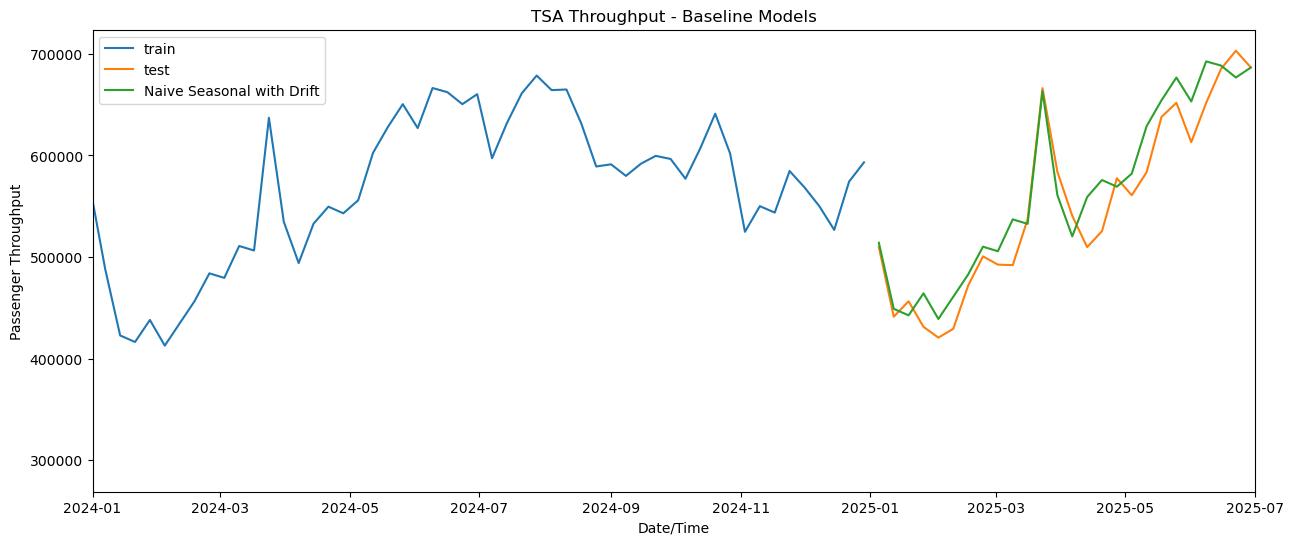

In [18]:
# Apply the Naive Seasonal model with Drift to the weekly data and calculate metrics
nswd_model = NaiveSeasonalWithDrift(season_length=52)
nswd_model.fit(ord_weekly_train.total_passenger_throughput)
nswd_forecast = nswd_model.forecast(h=len(ord_weekly_test))
nswd_metrics = evaluate_forecast(ord_weekly_test.total_passenger_throughput,
                                 nswd_forecast,
                                 "Naive Seasonal with Drift")
# Print metrics
print(f"\nNaive Seasonal with Drift:")
print(f"  MAE: {nswd_metrics['mae']:,.0f}")
print(f"  MAPE: {nswd_metrics['mape']*100:.2f}%")
print(f"  RMSE: {nswd_metrics['rmse']:,.0f}")
# Plot results
plt.figure(figsize=(15, 6))
plt.plot(ord_weekly_train.datetime, ord_weekly_train.total_passenger_throughput, label="train")
plt.plot(ord_weekly_test.datetime, ord_weekly_test.total_passenger_throughput, label="test")
plt.plot(ord_weekly_test.datetime, nswd_forecast, label="Naive Seasonal with Drift")
plt.title("TSA Throughput - Baseline Models")
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.xlim(pd.Timestamp("2024-01-01"), pd.Timestamp("2025-07-01"))
plt.legend()
plt.show()


Triple Exponential Smoothing:
  MAE: 26,768
  MAPE: 5.15%
  RMSE: 32,429


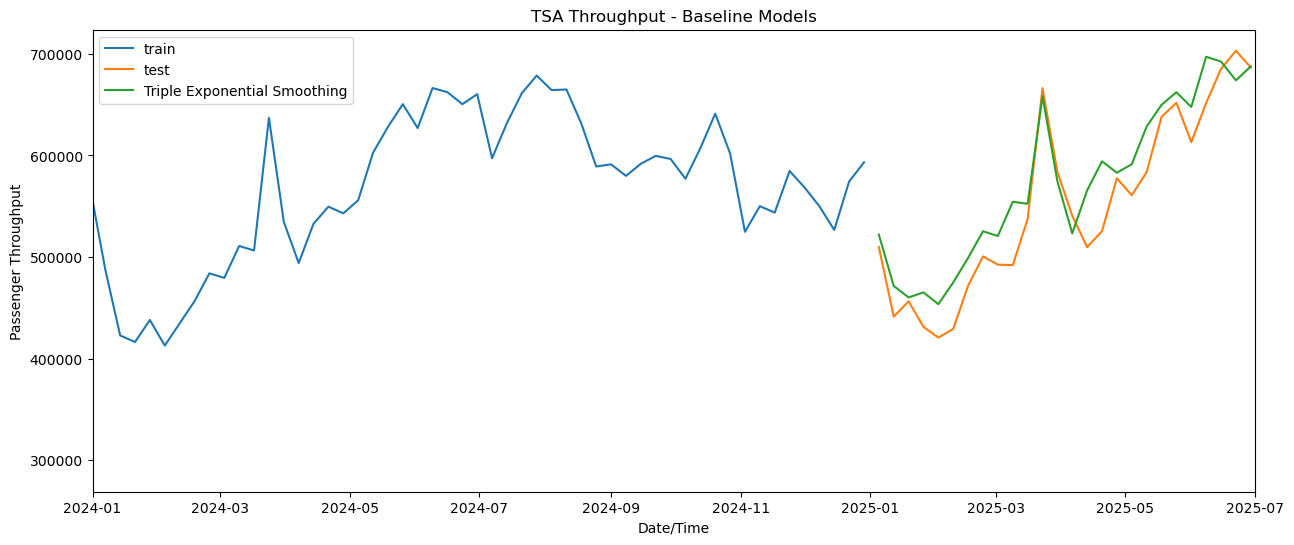

In [19]:
# Apply the Triple Exponential smoothing model to the daily data and calculate metrics
exps_model = TripleExponentialSmoothing(season_length=52)
exps_model.fit(ord_weekly_train.total_passenger_throughput)
exps_forecast = exps_model.forecast(h=len(ord_weekly_test))
exps_metrics = evaluate_forecast(ord_weekly_test.total_passenger_throughput,
                                 exps_forecast,
                                 "Triple Exponential Smoothing")
# Print metrics
print(f"\nTriple Exponential Smoothing:")
print(f"  MAE: {exps_metrics['mae']:,.0f}")
print(f"  MAPE: {exps_metrics['mape']*100:.2f}%")
print(f"  RMSE: {exps_metrics['rmse']:,.0f}")
# Plot results
plt.figure(figsize=(15, 6))
plt.plot(ord_weekly_train.datetime, ord_weekly_train.total_passenger_throughput, label="train")
plt.plot(ord_weekly_test.datetime, ord_weekly_test.total_passenger_throughput, label="test")
plt.plot(ord_weekly_test.datetime, exps_forecast, label="Triple Exponential Smoothing")
plt.title("TSA Throughput - Baseline Models")
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.xlim(pd.Timestamp("2024-01-01"), pd.Timestamp("2025-07-01"))
plt.legend()
plt.show()

Clearly with the weekly data the baseline models do a much better job of matching the trend. Here, the naive Seasonal with Drift model performs a bit better. This is the model we need to try to beat.

# Modelling Approach

## Data Splits

In [20]:
from busy_airports.data_splits import make_rolling_splits, make_rolling_splits_weekly

# Creating Daily Splits
print("\nDaily Splits:")
splits_d = make_rolling_splits(ord_daily, date_col='datetime', n_splits=5, step_days=90)
# Creating Weekly Splits
print("\nWeekly Splits:")
splits_w = make_rolling_splits_weekly(ord_weekly, date_col='datetime', n_splits=5, step_weeks=13)


Daily Splits:
Split 1: train → 2024-03-30 | test 2024-03-31 → 2024-06-28 (90 days)
Split 2: train → 2024-06-28 | test 2024-06-29 → 2024-09-26 (90 days)
Split 3: train → 2024-09-26 | test 2024-09-27 → 2024-12-25 (90 days)
Split 4: train → 2024-12-25 | test 2024-12-26 → 2025-03-25 (90 days)
Split 5: train → 2025-03-25 | test 2025-03-26 → 2025-06-23 (90 days)

Weekly Splits:
Split 1: train → row 116 (2024-03-31) | test rows 117–129 (2024-04-07 → 2024-06-30) (13 weeks)
Split 2: train → row 129 (2024-06-30) | test rows 130–142 (2024-07-07 → 2024-09-29) (13 weeks)
Split 3: train → row 142 (2024-09-29) | test rows 143–155 (2024-10-06 → 2024-12-29) (13 weeks)
Split 4: train → row 155 (2024-12-29) | test rows 156–168 (2025-01-05 → 2025-03-30) (13 weeks)
Split 5: train → row 168 (2025-03-30) | test rows 169–181 (2025-04-06 → 2025-06-29) (13 weeks)


## Baselines - Daily

Before evaluating our models, we must start by establishing the metrics for the baseline models across our time series splits.

In [31]:
# Daily Baseline - Naive Seasonal with Drift
results_nswd_d = []

for i, (train_idx, test_idx) in enumerate(splits_d, start=1):
        train = ord_daily.iloc[train_idx]
        test  = ord_daily.iloc[test_idx]

        model = NaiveSeasonalWithDrift(season_length=365)
        model.fit(train.total_passenger_throughput)
        forecasts = model.forecast(h=len(test))

        metrics = evaluate_forecast(test.total_passenger_throughput, forecasts, model_name=f"Split {i}")
        metrics['split'] = i
        results_nswd_d.append(metrics)
        print(f"Split {i} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")
        
results_nswd_d_df = pd.DataFrame(results_nswd_d).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_nswd_d_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_nswd_d_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_nswd_d_df['rmse'].mean():,.0f}")

Split 1 - MAE: 20708, MAPE: 23.64%, RMSE: 22981
Split 2 - MAE: 9248, MAPE: 10.88%, RMSE: 11511
Split 3 - MAE: 14555, MAPE: 19.38%, RMSE: 17957
Split 4 - MAE: 16882, MAPE: 23.29%, RMSE: 19221
Split 5 - MAE: 14919, MAPE: 16.93%, RMSE: 17854

CV Average:
  MAE:  15,263
  MAPE: 18.82%
  RMSE: 17,905


In [32]:
# Daily Baseline - Triple Exponential Smoothing
results_exps_d = []

for i, (train_idx, test_idx) in enumerate(splits_d, start=1):
        train = ord_daily.iloc[train_idx]
        test  = ord_daily.iloc[test_idx]

        model = TripleExponentialSmoothing(season_length=365)
        model.fit(train.total_passenger_throughput)
        forecasts = model.forecast(h=len(test))

        metrics = evaluate_forecast(test.total_passenger_throughput, forecasts, model_name=f"Split {i}")
        metrics['split'] = i
        results_exps_d.append(metrics)
        print(f"Split {i} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")
        
results_exps_d_df = pd.DataFrame(results_exps_d).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_exps_d_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_exps_d_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_exps_d_df['rmse'].mean():,.0f}")

Split 1 - MAE: 8690, MAPE: 10.38%, RMSE: 10283
Split 2 - MAE: 9452, MAPE: 11.43%, RMSE: 11930
Split 3 - MAE: 10609, MAPE: 13.82%, RMSE: 12786
Split 4 - MAE: 8558, MAPE: 12.83%, RMSE: 10457
Split 5 - MAE: 9530, MAPE: 11.50%, RMSE: 11713

CV Average:
  MAE:  9,368
  MAPE: 11.99%
  RMSE: 11,434


## STLArima - Daily

In [37]:
from busy_airports.models import STLArima
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

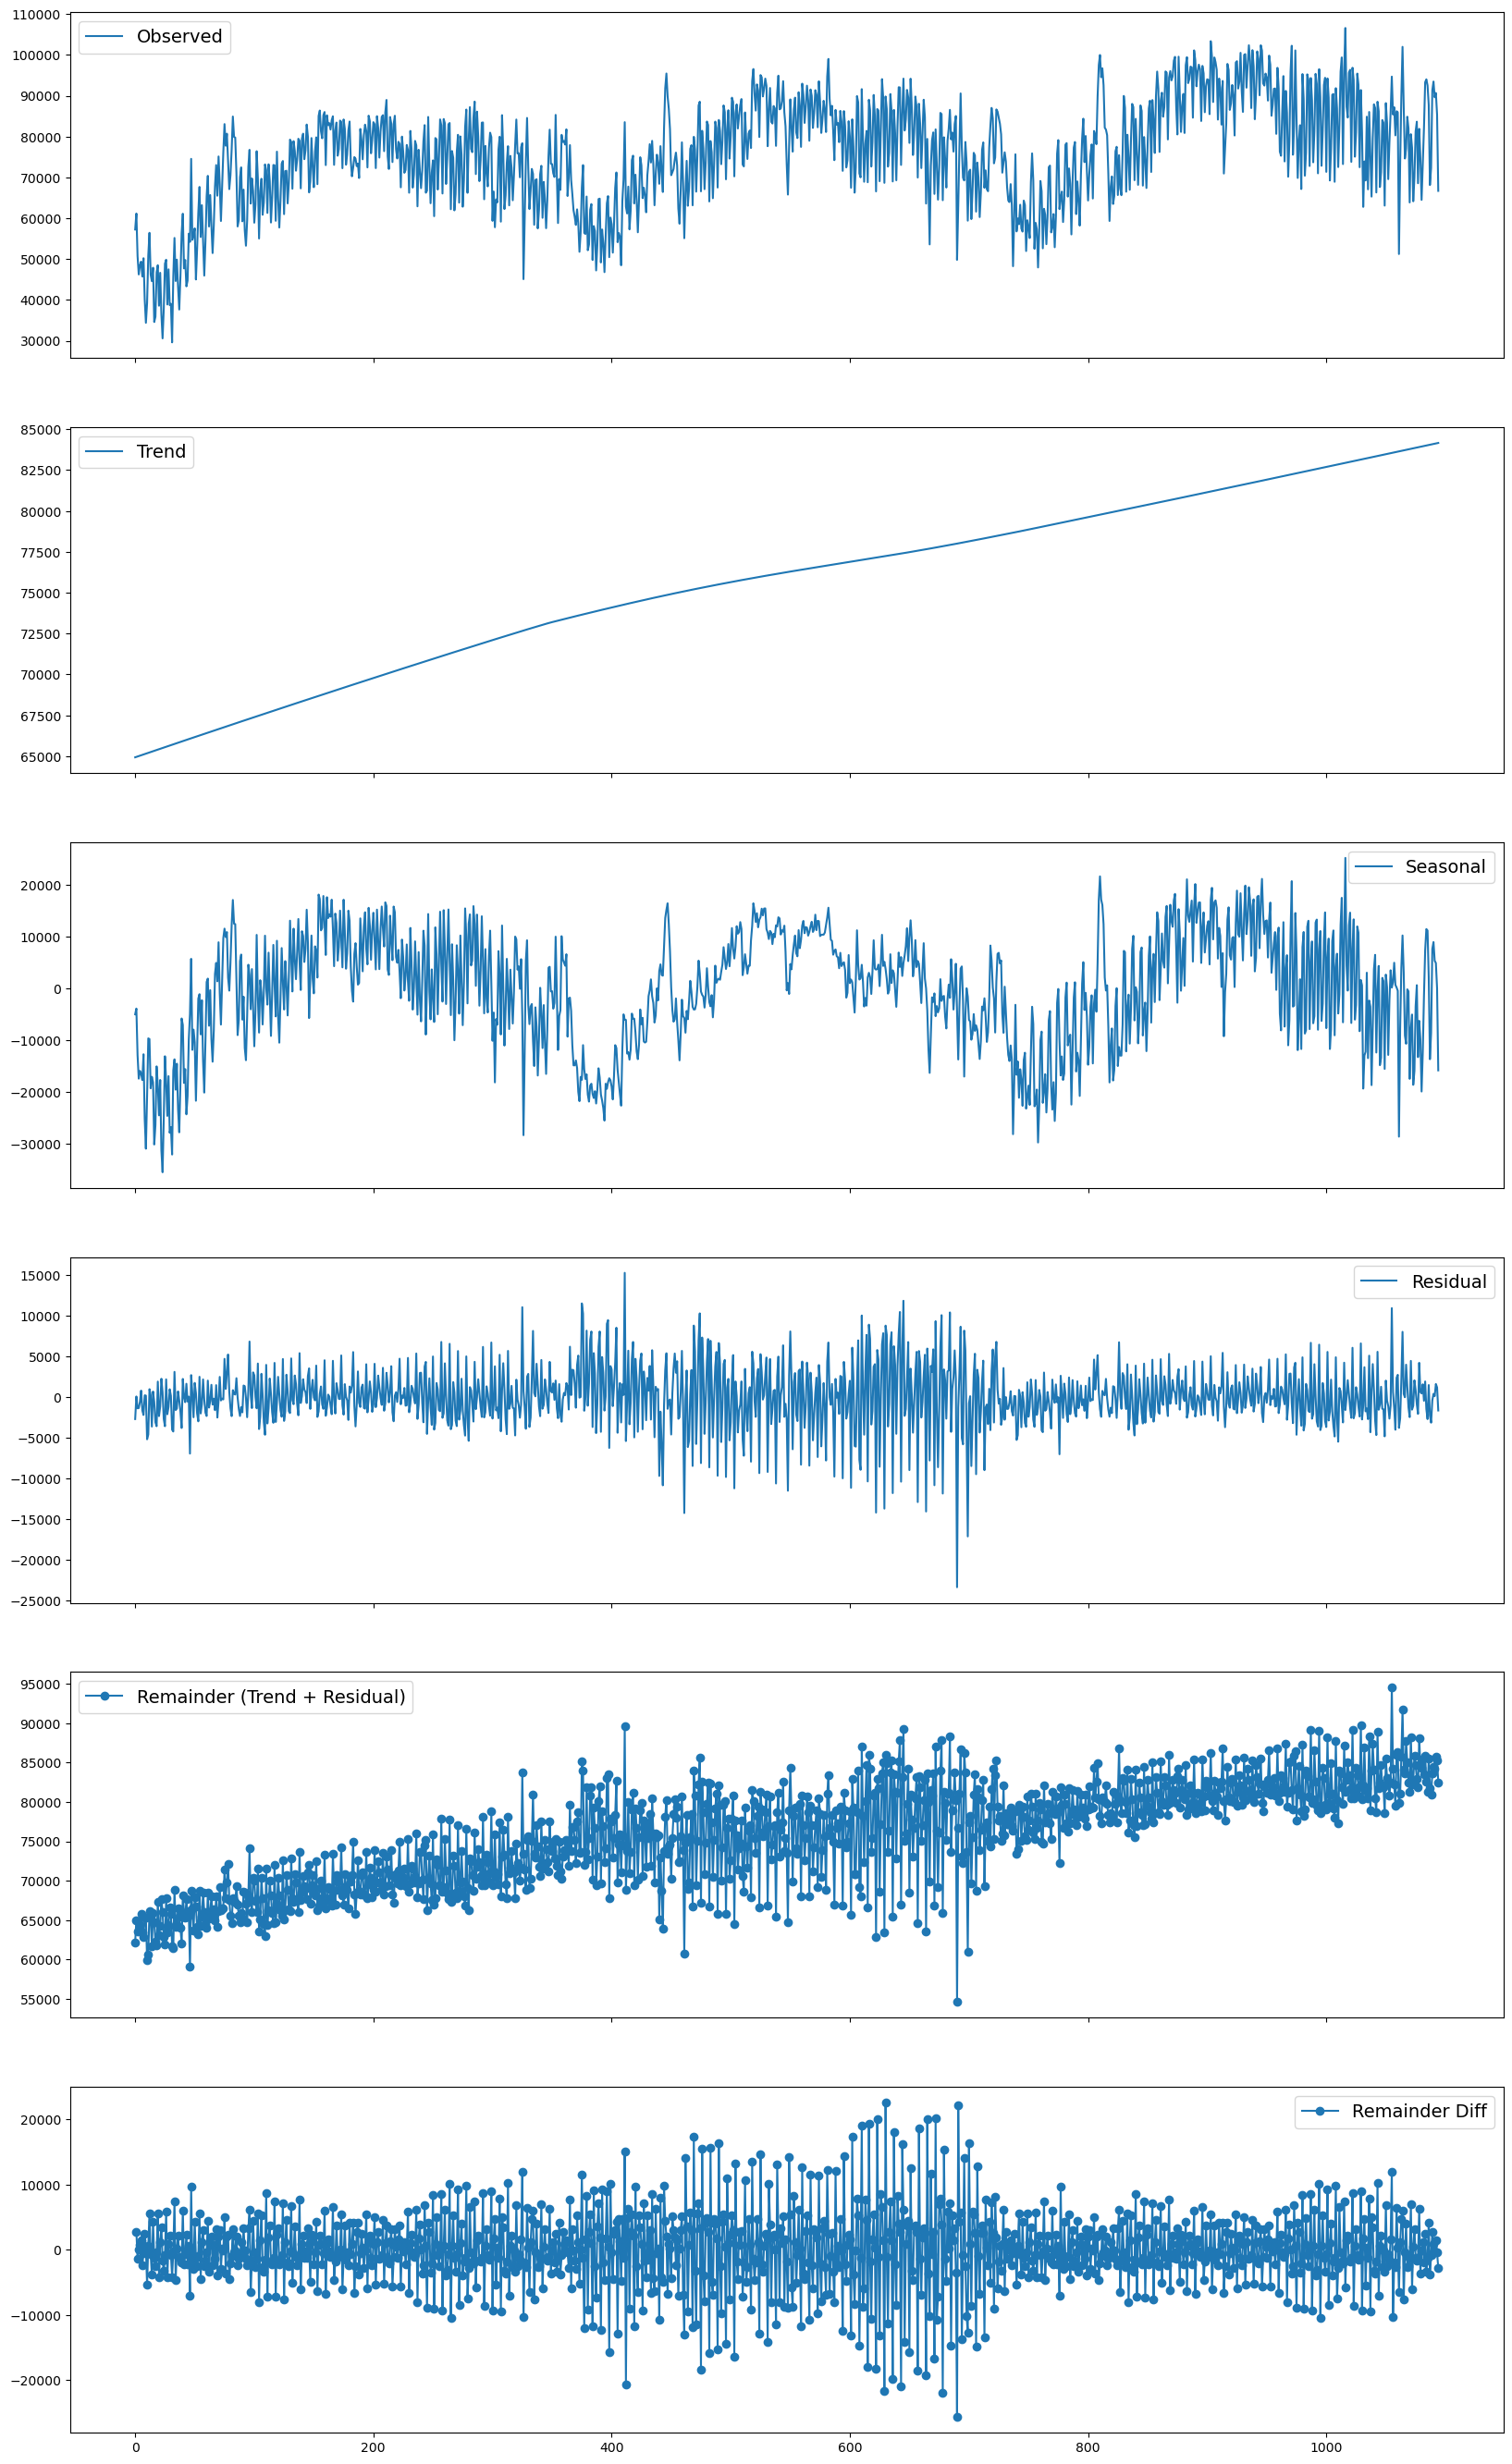

In [25]:
# Perform STL decomposition on the training set
stl_daily = STL(ord_daily_train['total_passenger_throughput'], period=365)
stl_daily_results = stl_daily.fit()

stl_daily_trend = stl_daily_results.trend
stl_daily_seasonal = stl_daily_results.seasonal
stl_daily_resid = stl_daily_results.resid
stl_daily_base = stl_daily_results.observed

stl_daily_trend_diff = stl_daily_trend.diff()
stl_daily_remainder = stl_daily_trend + stl_daily_resid
stl_daily_remainder_diff = stl_daily_remainder.diff()

fig, ax = plt.subplots(6, 1, figsize=(20, 34), sharex=True)
ax[0].plot(stl_daily_base, label='Observed')
ax[0].legend(fontsize=14)
ax[1].plot(stl_daily_trend, label='Trend')
ax[1].legend(fontsize=14)
ax[2].plot(stl_daily_seasonal, label='Seasonal')
ax[2].legend(fontsize=14)
ax[3].plot(stl_daily_resid, label='Residual')
ax[3].legend(fontsize=14)
ax[4].plot(stl_daily_remainder, label='Remainder (Trend + Residual)', marker='o')
ax[4].legend(fontsize=14)
ax[5].plot(stl_daily_remainder_diff, label='Remainder Diff', marker='o')
ax[5].legend(fontsize=14)
plt.show()

In [ ]:
# Obtain the auto arima model fitted to the STL remainder (trend + residuals)
# The autoarima method effectively does cross validation to select optimal hyperparameters
auto_arima(stl_daily_remainder, 
           seasonal=True,
           m=7,
           trace = True,
           stepwise=True)

```
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=20712.220, Time=1.06 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=22102.268, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=21292.591, Time=0.28 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=21057.601, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=22100.280, Time=0.01 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=20975.384, Time=0.70 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=20844.879, Time=0.76 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=20710.122, Time=1.81 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=20784.277, Time=1.61 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=inf, Time=2.27 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=20710.612, Time=1.70 sec
 ARIMA(1,1,2)(2,0,1)[7] intercept   : AIC=20901.631, Time=1.27 sec
 ARIMA(2,1,1)(2,0,1)[7] intercept   : AIC=20683.433, Time=1.58 sec
 ARIMA(2,1,1)(1,0,1)[7] intercept   : AIC=20685.749, Time=0.92 sec
 ARIMA(2,1,1)(2,0,0)[7] intercept   : AIC=inf, Time=1.48 sec
 ARIMA(2,1,1)(2,0,2)[7] intercept   : AIC=inf, Time=1.57 sec
 ARIMA(2,1,1)(1,0,0)[7] intercept   : AIC=20803.316, Time=0.68 sec
 ARIMA(2,1,1)(1,0,2)[7] intercept   : AIC=20683.779, Time=1.48 sec
 ARIMA(1,1,1)(2,0,1)[7] intercept   : AIC=20815.982, Time=1.20 sec
 ARIMA(2,1,0)(2,0,1)[7] intercept   : AIC=20863.331, Time=1.29 sec
 ARIMA(3,1,1)(2,0,1)[7] intercept   : AIC=20673.747, Time=1.97 sec
 ARIMA(3,1,1)(1,0,1)[7] intercept   : AIC=20675.032, Time=0.99 sec
 ARIMA(3,1,1)(2,0,0)[7] intercept   : AIC=20756.788, Time=1.40 sec
 ARIMA(3,1,1)(2,0,2)[7] intercept   : AIC=inf, Time=2.21 sec
...
 ARIMA(4,1,3)(1,0,2)[7]             : AIC=20616.764, Time=2.57 sec

Best model:  ARIMA(5,1,4)(1,0,2)[7]          
Total fit time: 178.432 seconds
```

In [ ]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Arima orders for the remainder component of the STL decomposition
# OLD: Best model:  ARIMA(5,1,2)(2,0,1)[7] 
# NEW: Best model:  ARIMA(5,1,4)(1,0,2)[7]

p, d, q = 5, 1, 2
P, D, Q, s = 1, 0, 2, 7

results_stl_d = []
# Running STL + ARIMA on daily data using the splits created above.
for i, (train_idx, test_idx) in enumerate(splits_d, start=1):
        train = ord_daily.iloc[train_idx]
        test  = ord_daily.iloc[test_idx]
        n_forecast = len(test_idx)

        model = STLArima(season_length=365, arima_order=(p,d,q), seasonal_order=(P,D,Q,s))
        model.fit(train['total_passenger_throughput'])
        forecasts, lower_bound, upper_bound = model.forecast(n_forecast)
        
        actuals  = test['total_passenger_throughput']
        metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i}")
        metrics['split'] = i
        results_stl_d.append(metrics)
        print(f"Split {i} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")

results_stl_d_df = pd.DataFrame(results_stl_d).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_stl_d_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_stl_d_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_stl_d_df['rmse'].mean():,.0f}")

Split 1 - MAE: 8691, MAPE: 10.46%, RMSE: 10341
Split 2 - MAE: 9185, MAPE: 10.66%, RMSE: 11411
Split 3 - MAE: 10366, MAPE: 13.34%, RMSE: 13362
Split 4 - MAE: 7948, MAPE: 11.84%, RMSE: 9891
Split 5 - MAE: 9762, MAPE: 11.96%, RMSE: 12145

CV Average:
  MAE:  9,190
  MAPE: 11.65%
  RMSE: 11,430


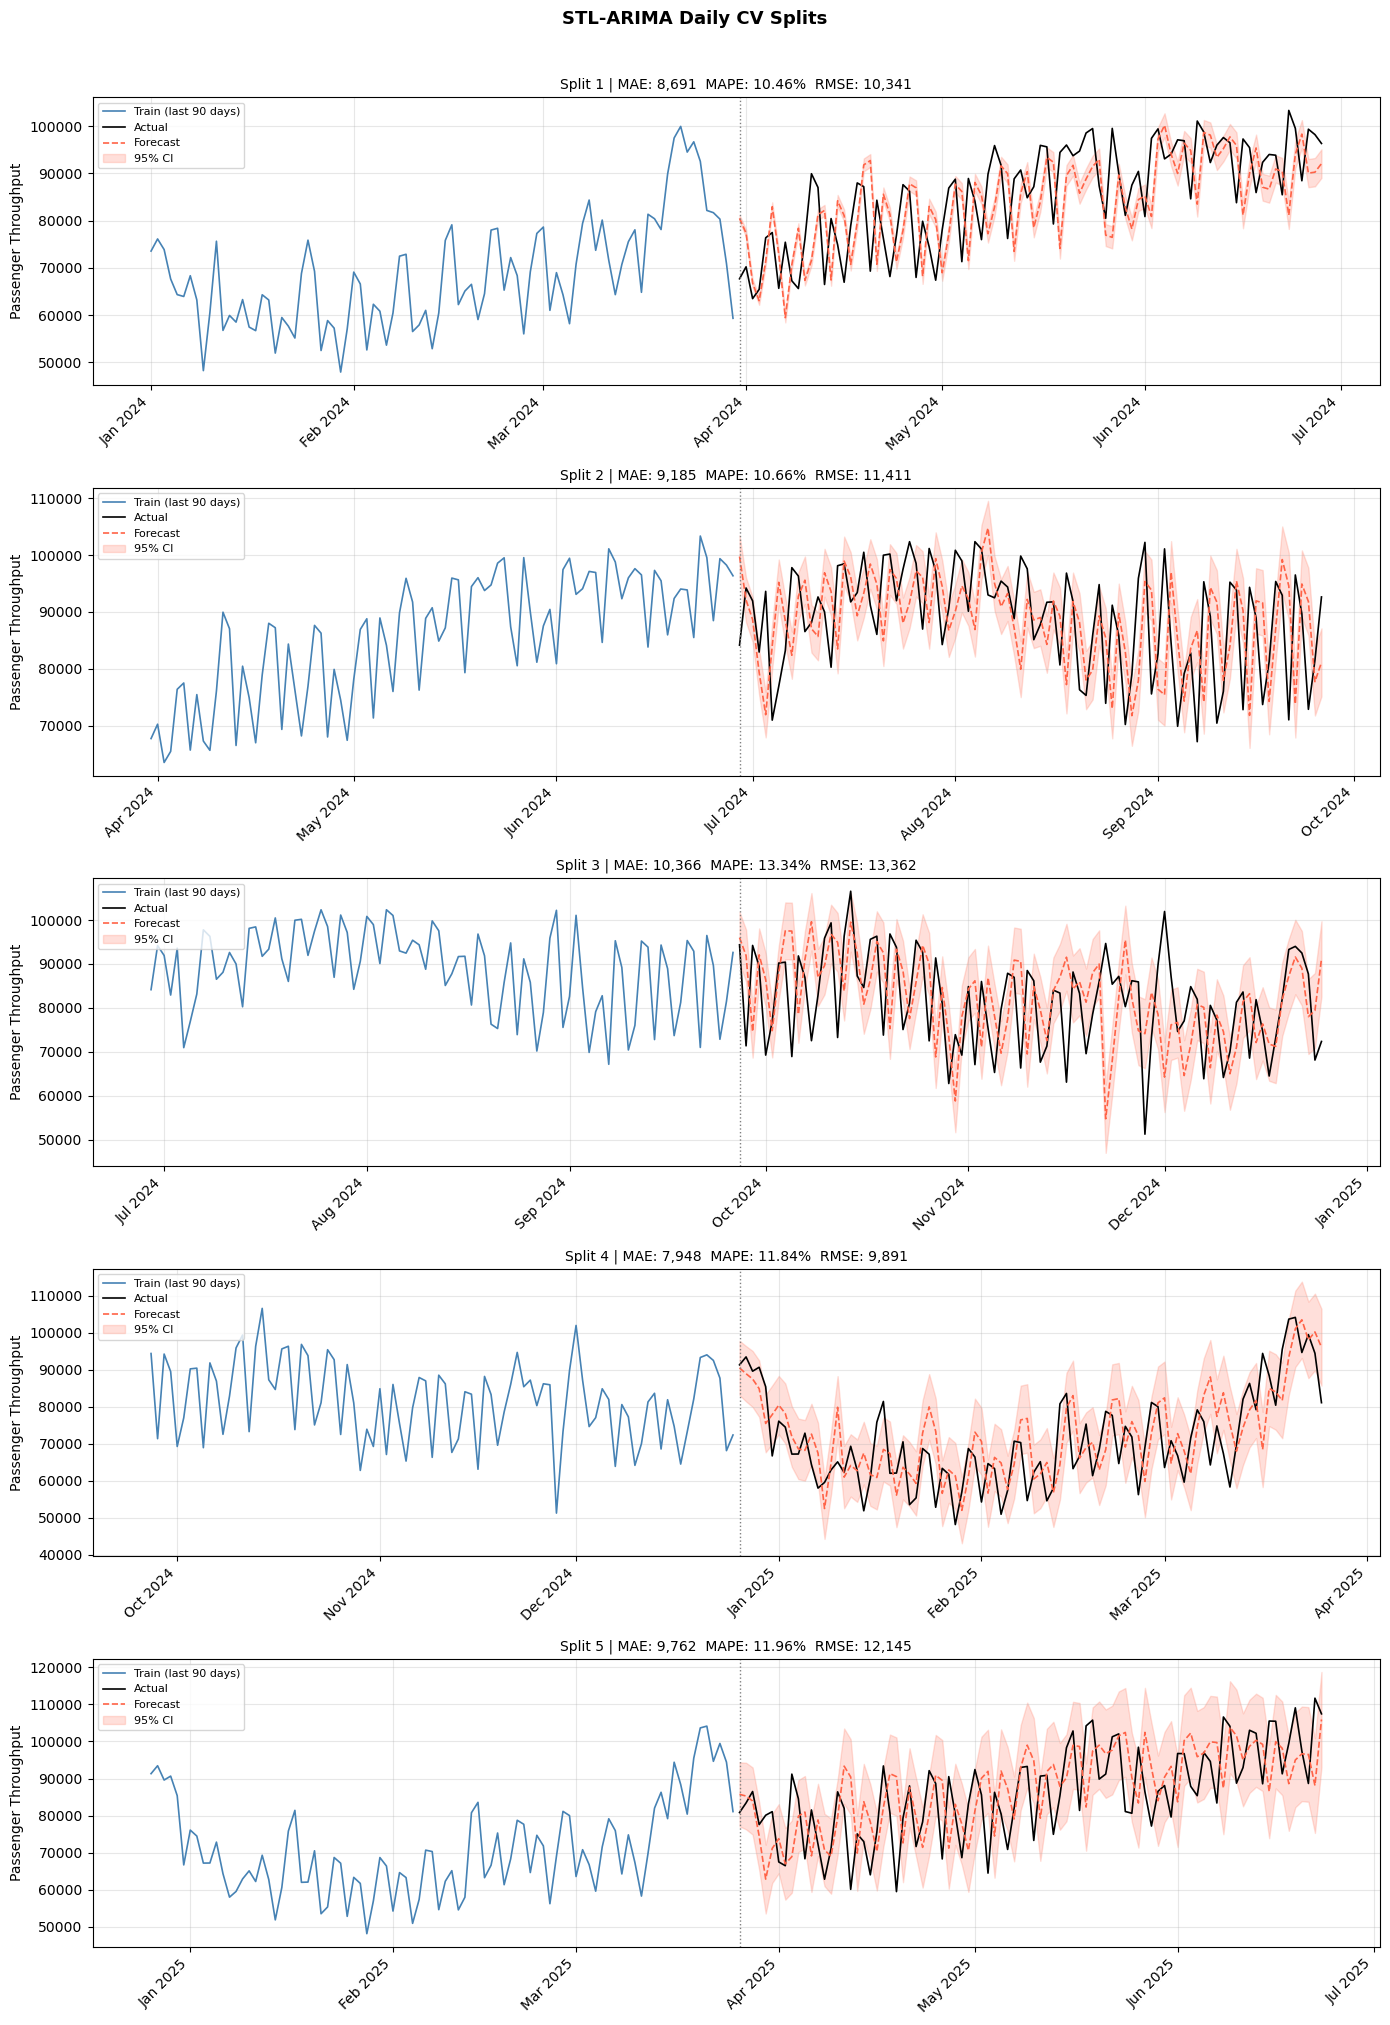

In [36]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(splits_d), 1, figsize=(14, 4 * len(splits_d)))
axes = axes if hasattr(axes, '__len__') else [axes]  # handle single split edge case

for i, (train_idx, test_idx) in enumerate(splits_d):
    ax = axes[i]

    train = ord_daily.iloc[train_idx]
    test  = ord_daily.iloc[test_idx]
    n_forecast = len(test_idx)

    model = STLArima(season_length=365, arima_order=(p,d,q), seasonal_order=(P,D,Q,s))
    model.fit(train['total_passenger_throughput'])
    forecasts, lower_bound, upper_bound = model.forecast(n_forecast)

    actuals = test['total_passenger_throughput']
    metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results_stl_d.append(metrics)

    # --- Plotting ---
    train_dates = train.datetime
    test_dates  = test.datetime

    # Plot last N days of training data for context
    context_window = min(90, len(train))
    ax.plot(train_dates.iloc[-context_window:],
            train['total_passenger_throughput'].iloc[-context_window:],
            color='steelblue', label='Train (last 90 days)', linewidth=1.2)

    # Actuals in test window
    ax.plot(test_dates, actuals,
            color='black', label='Actual', linewidth=1.2)

    # Forecast
    ax.plot(test_dates, forecasts,
            color='tomato', label='Forecast', linewidth=1.2, linestyle='--')

    # 95% Confidence interval
    ax.fill_between(test_dates, lower_bound, upper_bound,
                    color='tomato', alpha=0.2, label='95% CI')

    # Vertical line separating train/test
    ax.axvline(x=test_dates.iloc[0], color='gray', linestyle=':', linewidth=1)

    ax.set_title(
        f"Split {i+1} | MAE: {metrics['mae']:,.0f}  "
        f"MAPE: {100*metrics['mape']:.2f}%  "
        f"RMSE: {metrics['rmse']:,.0f}",
        fontsize=10
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_ylabel('Passenger Throughput')
    ax.grid(True, alpha=0.3)

plt.suptitle('STL-ARIMA Daily CV Splits', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Harmonic ARIMA - Daily

In [43]:
from busy_airports.models import fourier_features, HarmonicARIMA
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

For Harmonic ARIMA, first we must determine the optimal number of frequencies to use in the Harmonic part of the model. We do so by modeling the data using Linear Regression with the Fourier features.

In [44]:
from sklearn.linear_model import LinearRegression


Minimum metrics:
  MAE:  (18, 9,944)
  MAPE: (18, 0.12%)
  RMSE: (18, 11,796)


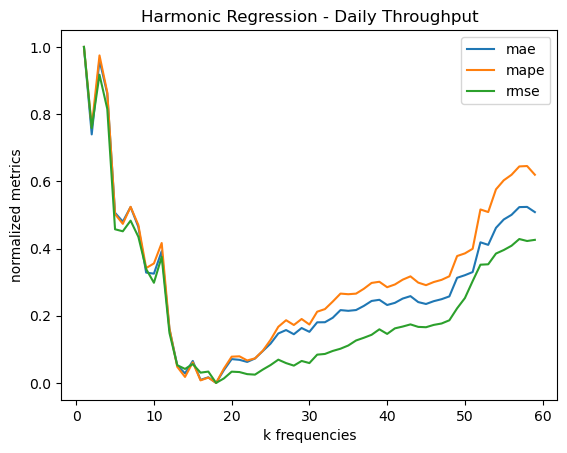

In [24]:
# Average the metrics over all folds for each choice of k_frequency
results = []

for k_freq in range(1, 60):
    # Determine Fourier features for the given number of frequencies
    ord_daily_X = fourier_features(ord_daily['day'], m=365, k=k_freq)
    
    k_metrics = []

    for i, (train_idx, test_idx) in enumerate(splits_d, start = 1):
        X_train = ord_daily_X[train_idx]
        X_test  = ord_daily_X[test_idx]
        y_train = ord_daily.iloc[train_idx].total_passenger_throughput
        y_test  = ord_daily.iloc[test_idx].total_passenger_throughput

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = evaluate_forecast(y_test, y_pred, f"Split {i}")
        metrics['split'] = i
        k_metrics.append(metrics)
    
    metrics_df = pd.DataFrame(k_metrics).set_index('split')
    mean_metrics = {}
    mean_metrics['k_freq'] = k_freq
    mean_metrics['mae']  = metrics_df['mae'].mean()
    mean_metrics['mape'] = metrics_df['mape'].mean()
    mean_metrics['rmse'] = metrics_df['rmse'].mean()
    results.append(mean_metrics)

results_df = pd.DataFrame(results).set_index('k_freq')

print(f"\nMinimum metrics:")
print(f"  MAE:  ({results_df['mae'].idxmin()}, {results_df['mae'].min():,.0f})")
print(f"  MAPE: ({results_df['mape'].idxmin()}, {results_df['mape'].min():.2f}%)")
print(f"  RMSE: ({results_df['rmse'].idxmin()}, {results_df['rmse'].min():,.0f})")

# Normalize all metrics between 0 and 1 for comparison
results_df = (results_df - results_df.min()) / (results_df.max() - results_df.min())
results_df.plot()
plt.title('Harmonic Regression - Daily Throughput')
plt.xlabel('k frequencies')
plt.ylabel('normalized metrics')
plt.legend()
plt.show()

These results demonstrate that the optimal choice of `k_frequencies` for capturing the annual trend appears to be about 18.

We can now apply `autoarima` using the optimal number of Fourier features and the largest set of training data. This will allow us to determine the optimal SARIMA model to use to capture the weekly trend and the errors in the data.

**Note**: This cell can take a very long time. Run at your own peril.

In [ ]:
# Create optimal number of Fourier features to model annual trend
ord_daily_X = fourier_features(ord_daily['day'], m=365, k=18)
# Take largest split for determining optimal SARIMA model
X_train = ord_daily_X[splits_d[-1][0]]
X_test  = ord_daily_X[splits_d[-1][1]]
y_train = ord_daily.iloc[splits_d[-1][0]].total_passenger_throughput
y_test  = ord_daily.iloc[splits_d[-1][1]].total_passenger_throughput

arima_model = auto_arima(
    y_train,
    X=X_train,
    seasonal=True, m=7,
    d=1, D=0, # d = 1 captures linear trend, D = 0 for simplicity (no observed week-by-week trend)
    stepwise=True,
    trace=True
)

```
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=16516.956, Time=219.82 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=17333.498, Time=0.60 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=16856.580, Time=88.77 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=16800.379, Time=146.52 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=22000.712, Time=0.63 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=16711.257, Time=96.32 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=16619.793, Time=188.92 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=inf, Time=284.26 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=16517.340, Time=264.22 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=16811.825, Time=13.61 sec
 ARIMA(2,1,2)(0,0,2)[7] intercept   : AIC=16640.669, Time=128.55 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=16559.234, Time=232.64 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=inf, Time=259.51 sec
 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=16549.225, Time=237.22 sec
 ARIMA(2,1,1)(1,0,1)[7] intercept   : AIC=16523.737, Time=200.78 sec
 ARIMA(3,1,2)(1,0,1)[7] intercept   : AIC=16468.958, Time=238.60 sec
 ARIMA(3,1,2)(0,0,1)[7] intercept   : AIC=16689.594, Time=94.26 sec
 ARIMA(3,1,2)(1,0,0)[7] intercept   : AIC=16584.472, Time=207.48 sec
 ARIMA(3,1,2)(2,0,1)[7] intercept   : AIC=16470.243, Time=299.33 sec
 ARIMA(3,1,2)(1,0,2)[7] intercept   : AIC=16475.914, Time=277.73 sec
 ARIMA(3,1,2)(0,0,0)[7] intercept   : AIC=16783.784, Time=16.18 sec
 ARIMA(3,1,2)(0,0,2)[7] intercept   : AIC=16609.874, Time=135.62 sec
 ARIMA(3,1,2)(2,0,0)[7] intercept   : AIC=16516.541, Time=274.54 sec
 ARIMA(3,1,2)(2,0,2)[7] intercept   : AIC=inf, Time=274.71 sec
...
 ARIMA(5,1,1)(1,0,1)[7] intercept   : AIC=16484.386, Time=265.53 sec
 ARIMA(5,1,3)(1,0,1)[7] intercept   : AIC=inf, Time=289.63 sec
 ARIMA(4,1,2)(1,0,1)[7]             : AIC=16371.907, Time=146.01 sec
 ARIMA(4,1,2)(0,0,1)[7]             : AIC=16671.967, Time=94.53 sec

Best model:  ARIMA(4,1,2)(1,0,1)[7]
```

After running the `autoarima`, we find that the optimal SARIMA model is `ARIMA(4,1,2)(1,0,1)[7]` with no intercept.

Finally, we can apply this model across all the splits and see what metrics we obtain.

In [29]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

results_harm_arima_d = []

for i, (train_idx, test_idx) in enumerate(splits_d, start=1):
        train = ord_daily.iloc[train_idx]
        test  = ord_daily.iloc[test_idx]

        model = HarmonicARIMA(harmonic_m=365,
                              harmonic_k=18,
                              arima_order=(4,1,2), 
                              seasonal_order=(1,0,1,7),
                              with_intercept=False)
        model.fit(train.day, train.total_passenger_throughput)
        forecasts, lower_bound, upper_bound = model.forecast(test.day)

        metrics = evaluate_forecast(test.total_passenger_throughput, forecasts, model_name=f"Split {i}")
        metrics['split'] = i
        results_harm_arima_d.append(metrics)
        print(f"Split {i} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")
        
results_harm_arima_d_df = pd.DataFrame(results_harm_arima_d).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_harm_arima_d_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_harm_arima_d_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_harm_arima_d_df['rmse'].mean():,.0f}")

Split 1 - MAE: 10986, MAPE: 12.36%, RMSE: 12278
Split 2 - MAE: 4874, MAPE: 5.94%, RMSE: 6691
Split 3 - MAE: 6092, MAPE: 8.06%, RMSE: 8064
Split 4 - MAE: 4771, MAPE: 6.46%, RMSE: 6161
Split 5 - MAE: 5438, MAPE: 6.34%, RMSE: 6725

CV Average:
  MAE:  6,432
  MAPE: 7.83%
  RMSE: 7,984


The metrics here are much lower than the STL + ARIMA model from earlier, and they beat the baseline models. This model appears to be the best candidate for forecasting the daily throughput data!

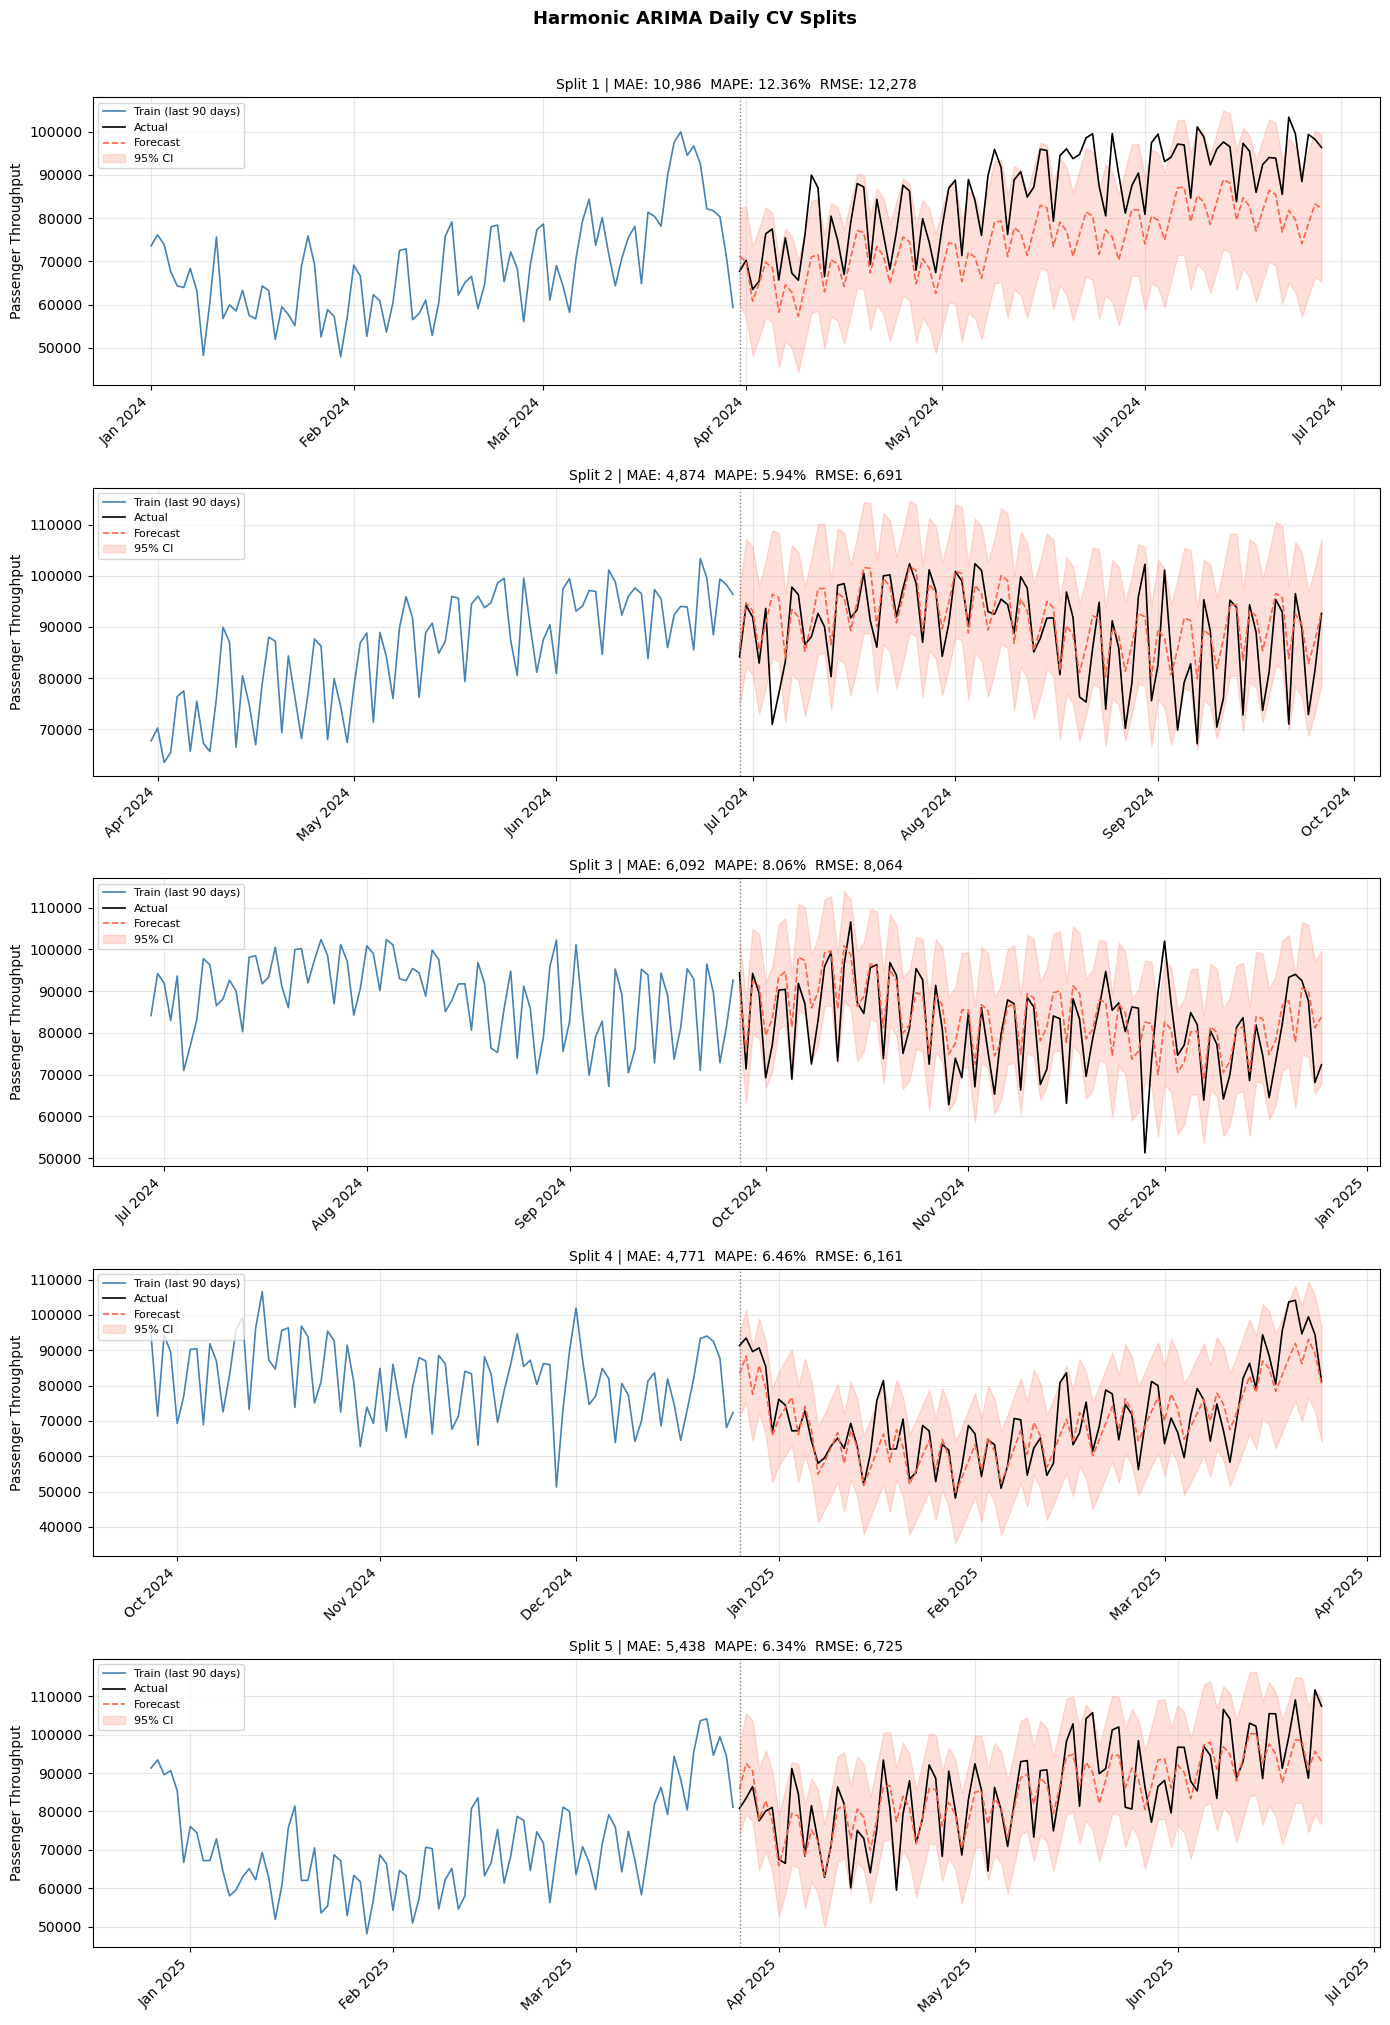

In [30]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(splits_d), 1, figsize=(14, 4 * len(splits_d)))
axes = axes if hasattr(axes, '__len__') else [axes]  # handle single split edge case

for i, (train_idx, test_idx) in enumerate(splits_d):
    ax = axes[i]

    train = ord_daily.iloc[train_idx]
    test  = ord_daily.iloc[test_idx]

    model = HarmonicARIMA(harmonic_m=365,
                              harmonic_k=18,
                              arima_order=(4,1,2), 
                              seasonal_order=(1,0,1,7),
                              with_intercept=False)
    model.fit(train.day, train.total_passenger_throughput)
    forecasts, lower_bound, upper_bound = model.forecast(test.day)

    actuals = test.total_passenger_throughput
    metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")

    # --- Plotting ---
    train_dates = train.datetime
    test_dates  = test.datetime

    # Plot last N days of training data for context
    context_window = min(90, len(train))
    ax.plot(train_dates.iloc[-context_window:],
            train['total_passenger_throughput'].iloc[-context_window:],
            color='steelblue', label='Train (last 90 days)', linewidth=1.2)

    # Actuals in test window
    ax.plot(test_dates, actuals,
            color='black', label='Actual', linewidth=1.2)

    # Forecast
    ax.plot(test_dates, forecasts,
            color='tomato', label='Forecast', linewidth=1.2, linestyle='--')

    # 95% Confidence interval
    ax.fill_between(test_dates, lower_bound, upper_bound,
                    color='tomato', alpha=0.2, label='95% CI')

    # Vertical line separating train/test
    ax.axvline(x=test_dates.iloc[0], color='gray', linestyle=':', linewidth=1)

    ax.set_title(
        f"Split {i+1} | MAE: {metrics['mae']:,.0f}  "
        f"MAPE: {100*metrics['mape']:.2f}%  "
        f"RMSE: {metrics['rmse']:,.0f}",
        fontsize=10
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_ylabel('Passenger Throughput')
    ax.grid(True, alpha=0.3)

plt.suptitle('Harmonic ARIMA Daily CV Splits', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Baselines - Weekly

Before evaluating our weekly models, we must start by establishing the metrics for the baseline models across our time series splits.

In [34]:
# Weekly Baseline - Naive Seasonal with Drift
results_nswd_w = []

for i, (train_idx, test_idx) in enumerate(splits_w, start=1):
        train = ord_weekly.iloc[train_idx]
        test  = ord_weekly.iloc[test_idx]

        model = NaiveSeasonalWithDrift(season_length=52)
        model.fit(train.total_passenger_throughput)
        forecasts = model.forecast(h=len(test))

        metrics = evaluate_forecast(test.total_passenger_throughput, forecasts, model_name=f"Split {i}")
        metrics['split'] = i
        results_nswd_w.append(metrics)
        print(f"Split {i} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")
        
results_nswd_w_df = pd.DataFrame(results_nswd_w).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_nswd_w_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_nswd_w_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_nswd_w_df['rmse'].mean():,.0f}")

Split 1 - MAE: 24071, MAPE: 3.90%, RMSE: 28144
Split 2 - MAE: 14224, MAPE: 2.28%, RMSE: 15503
Split 3 - MAE: 21894, MAPE: 3.79%, RMSE: 25913
Split 4 - MAE: 16755, MAPE: 3.56%, RMSE: 20865
Split 5 - MAE: 41694, MAPE: 7.08%, RMSE: 48477

CV Average:
  MAE:  23,728
  MAPE: 4.12%
  RMSE: 27,781


In [36]:
# Weekly Baseline - Triple Exponential Smoothing
results_exps_w = []

for i, (train_idx, test_idx) in enumerate(splits_w, start=1):
        train = ord_weekly.iloc[train_idx]
        test  = ord_weekly.iloc[test_idx]

        model = TripleExponentialSmoothing(season_length=52)
        model.fit(train.total_passenger_throughput)
        forecasts = model.forecast(h=len(test))

        metrics = evaluate_forecast(test.total_passenger_throughput, forecasts, model_name=f"Split {i}")
        metrics['split'] = i
        results_exps_w.append(metrics)
        print(f"Split {i} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")
        
results_exps_w_df = pd.DataFrame(results_exps_w).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_exps_w_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_exps_w_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_exps_w_df['rmse'].mean():,.0f}")

Split 1 - MAE: 10010, MAPE: 1.66%, RMSE: 13273
Split 2 - MAE: 16351, MAPE: 2.60%, RMSE: 18889
Split 3 - MAE: 26545, MAPE: 4.69%, RMSE: 29981
Split 4 - MAE: 25652, MAPE: 5.47%, RMSE: 30133
Split 5 - MAE: 26140, MAPE: 4.53%, RMSE: 32891

CV Average:
  MAE:  20,940
  MAPE: 3.79%
  RMSE: 25,033


Clearly these baselines perform much better than they did when applied to the daily data. The annual seasonality is much clearer in the weekly data and is essentially the only seasonality in the data. This is much simpler than the two seasonalities that occured in the daily data. These baselines will inevitably be much harder to beat.

## STLArima - Weekly

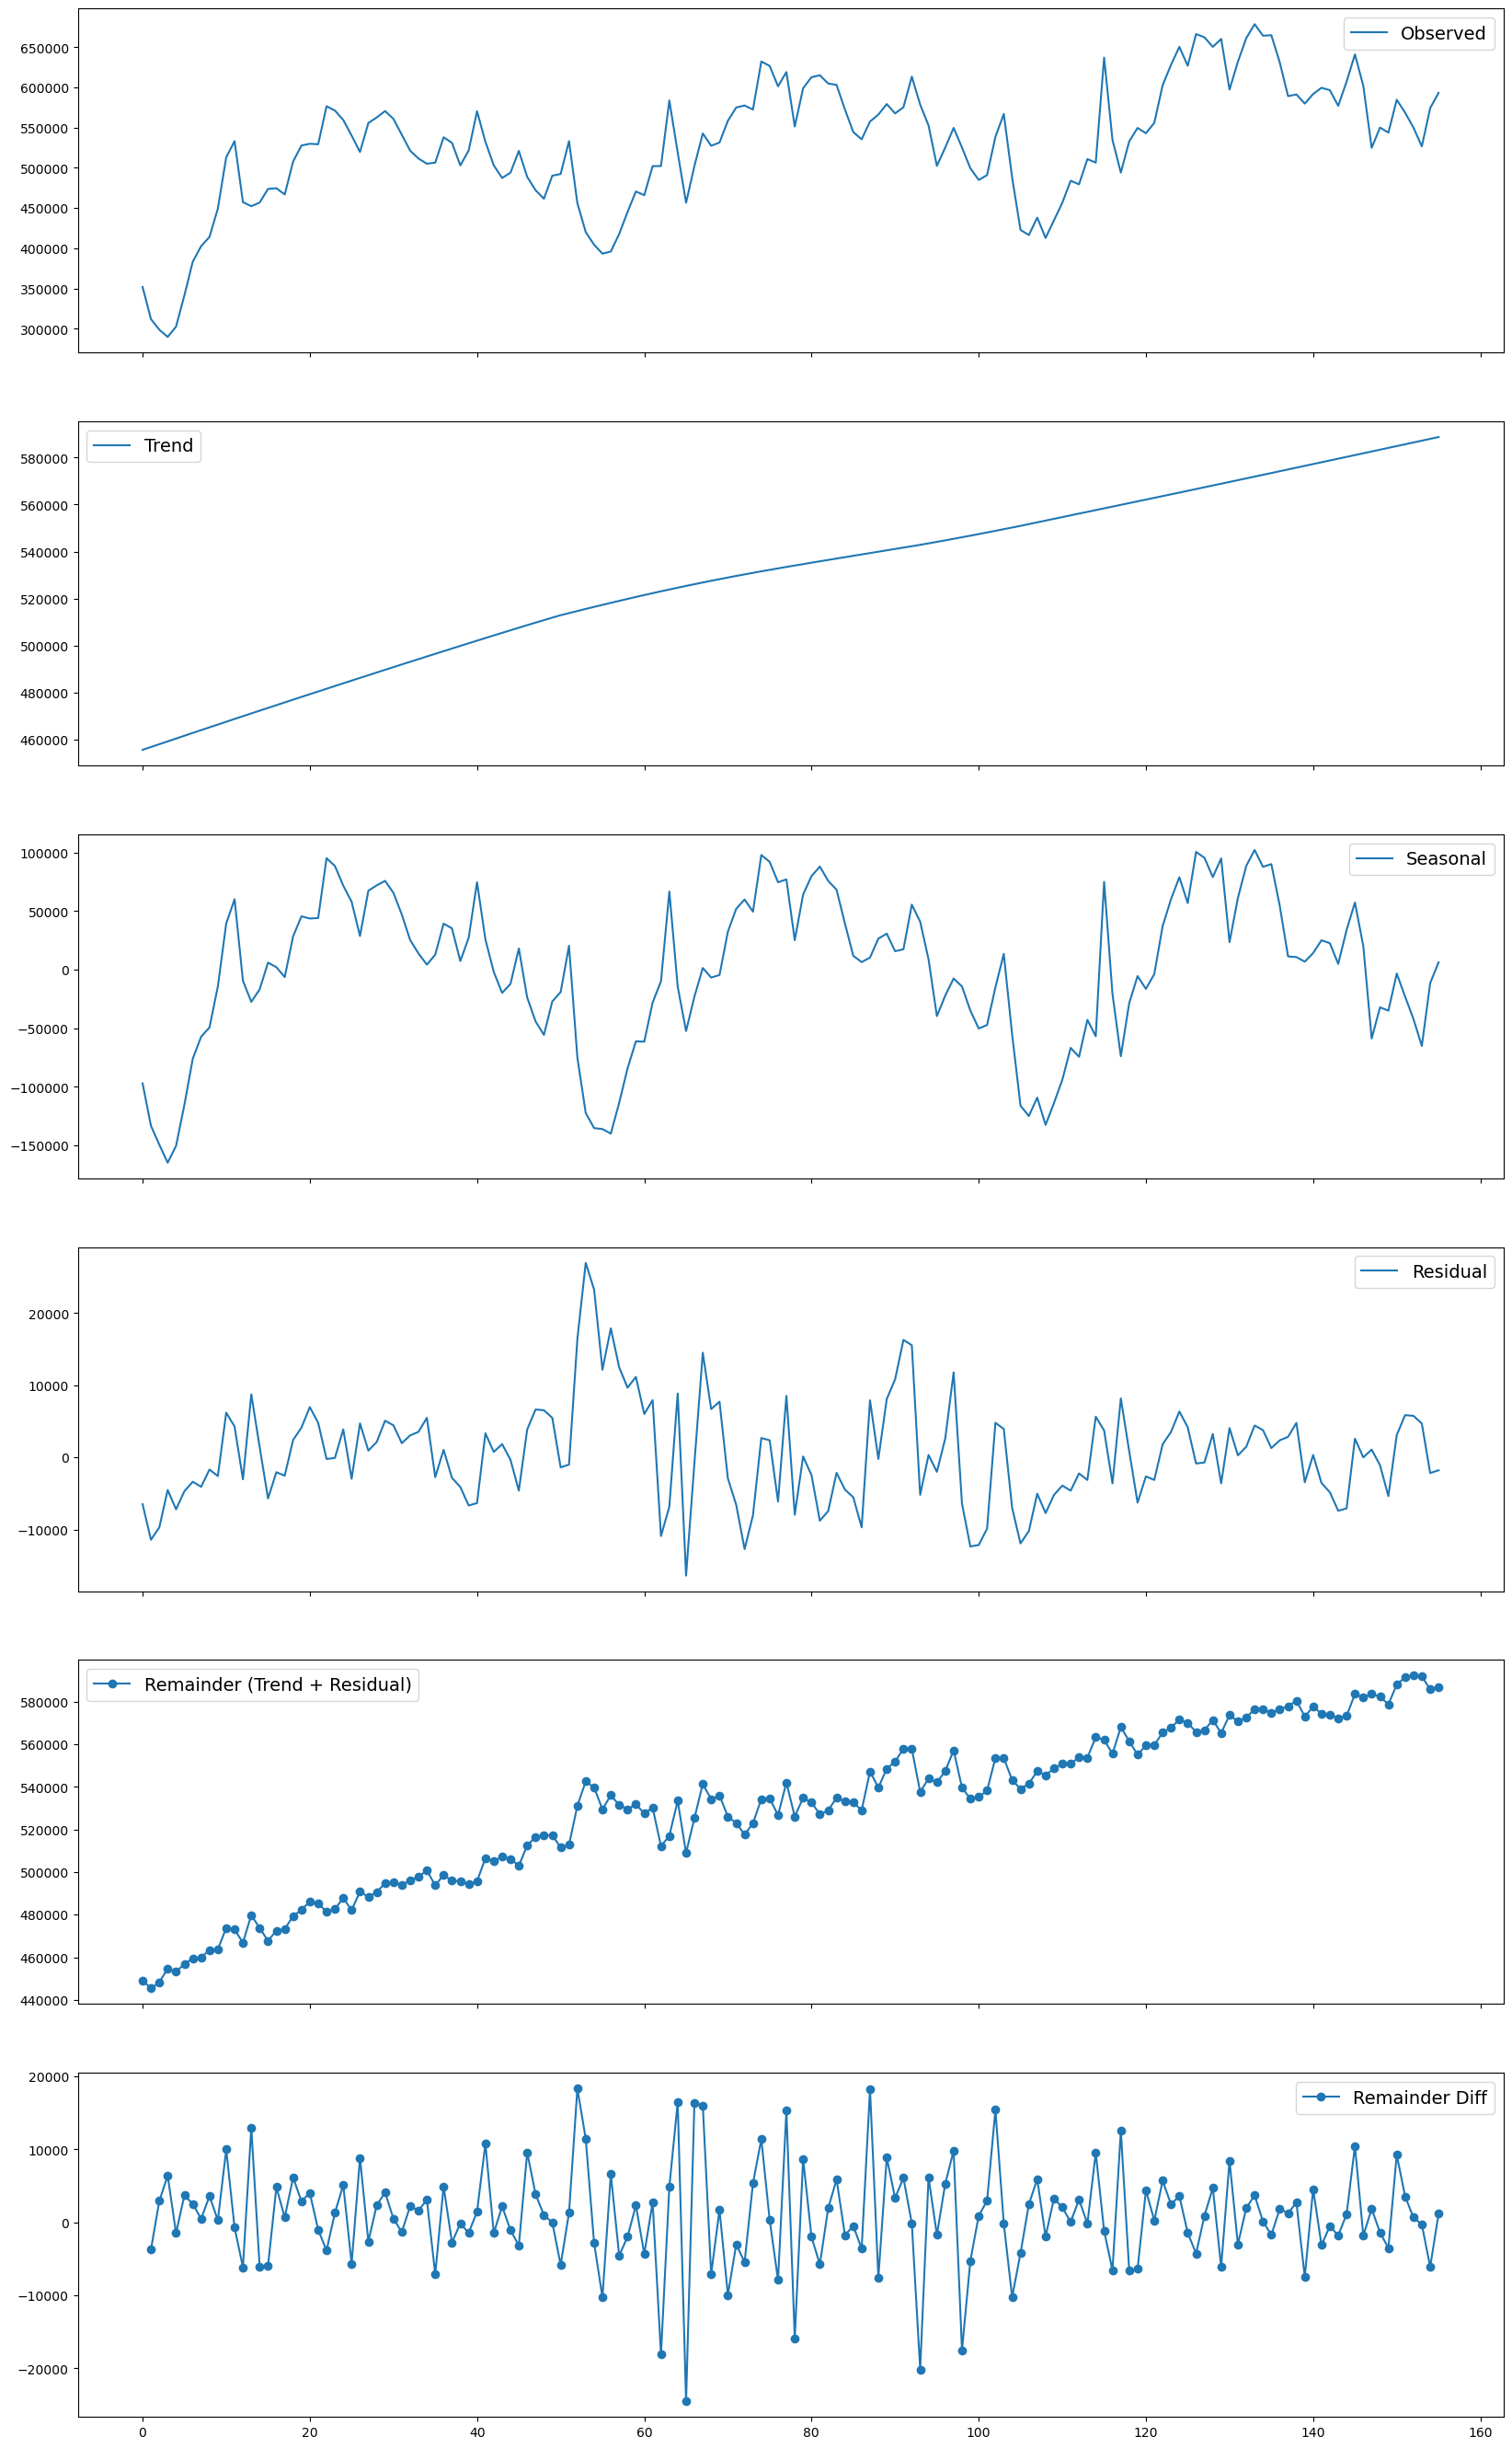

In [38]:
# Perform STL decomposition on the training set
stl_weekly = STL(ord_weekly_train['total_passenger_throughput'], period=52)
stl_weekly_results = stl_weekly.fit()

stl_weekly_trend = stl_weekly_results.trend
stl_weekly_seasonal = stl_weekly_results.seasonal
stl_weekly_resid = stl_weekly_results.resid
stl_weekly_base = stl_weekly_results.observed

stl_weekly_trend_diff = stl_weekly_trend.diff()
stl_weekly_remainder = stl_weekly_trend + stl_weekly_resid
stl_weekly_remainder_diff = stl_weekly_remainder.diff()

fig, ax = plt.subplots(6, 1, figsize=(20, 34), sharex=True)
ax[0].plot(stl_weekly_base, label='Observed')
ax[0].legend(fontsize=14)
ax[1].plot(stl_weekly_trend, label='Trend')
ax[1].legend(fontsize=14)
ax[2].plot(stl_weekly_seasonal, label='Seasonal')
ax[2].legend(fontsize=14)
ax[3].plot(stl_weekly_resid, label='Residual')
ax[3].legend(fontsize=14)
ax[4].plot(stl_weekly_remainder, label='Remainder (Trend + Residual)', marker='o')
ax[4].legend(fontsize=14)
ax[5].plot(stl_weekly_remainder_diff, label='Remainder Diff', marker='o')
ax[5].legend(fontsize=14)
plt.show()

In [39]:
# Obtain the auto arima model fitted to the STL remainder (trend + residuals)
# The autoarima method effectively does cross validation to select optimal hyperparameters
auto_arima(stl_weekly_remainder,
           seasonal=False,
           trace = True,
           stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.42 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3183.535, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3184.251, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3185.001, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3184.102, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3186.079, Time=0.10 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.700 seconds


,order,"(0, ...)"
,seasonal_order,"(0, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,True
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,{}
,trend,None
,with_intercept,True


In [40]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Arima orders for the remainder component of the STL decomposition
# Best model:  ARIMA(0,1,0)(0,0,0)[0]

p, d, q = 0, 1, 0
P, D, Q, s = 0, 0, 0, 0

results_stl_w = []
# Running STL + ARIMA on weekly data using the splits created above.
for i, (train_idx, test_idx) in enumerate(splits_w, start=1):
        train = ord_weekly.iloc[train_idx]
        test  = ord_weekly.iloc[test_idx]
        n_forecast = len(test_idx)

        model = STLArima(season_length=52, arima_order=(p,d,q), seasonal_order=(P,D,Q,s))
        model.fit(train['total_passenger_throughput'])
        forecasts, lower_bound, upper_bound = model.forecast(n_forecast)
        
        actuals  = test['total_passenger_throughput']
        metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i}")
        metrics['split'] = i
        results_stl_w.append(metrics)
        print(f"Split {i} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")

results_stl_w_df = pd.DataFrame(results_stl_w).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_stl_w_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_stl_w_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_stl_w_df['rmse'].mean():,.0f}")

Split 1 - MAE: 15545, MAPE: 2.56%, RMSE: 19029
Split 2 - MAE: 13794, MAPE: 2.19%, RMSE: 15848
Split 3 - MAE: 22343, MAPE: 3.89%, RMSE: 26690
Split 4 - MAE: 22879, MAPE: 4.91%, RMSE: 27775
Split 5 - MAE: 30219, MAPE: 5.17%, RMSE: 36578

CV Average:
  MAE:  20,956
  MAPE: 3.74%
  RMSE: 25,184


This model ever so slightly beats the best baseline model (exponential smoothing). Looking at individual splits, it seems like the models perform about the same.

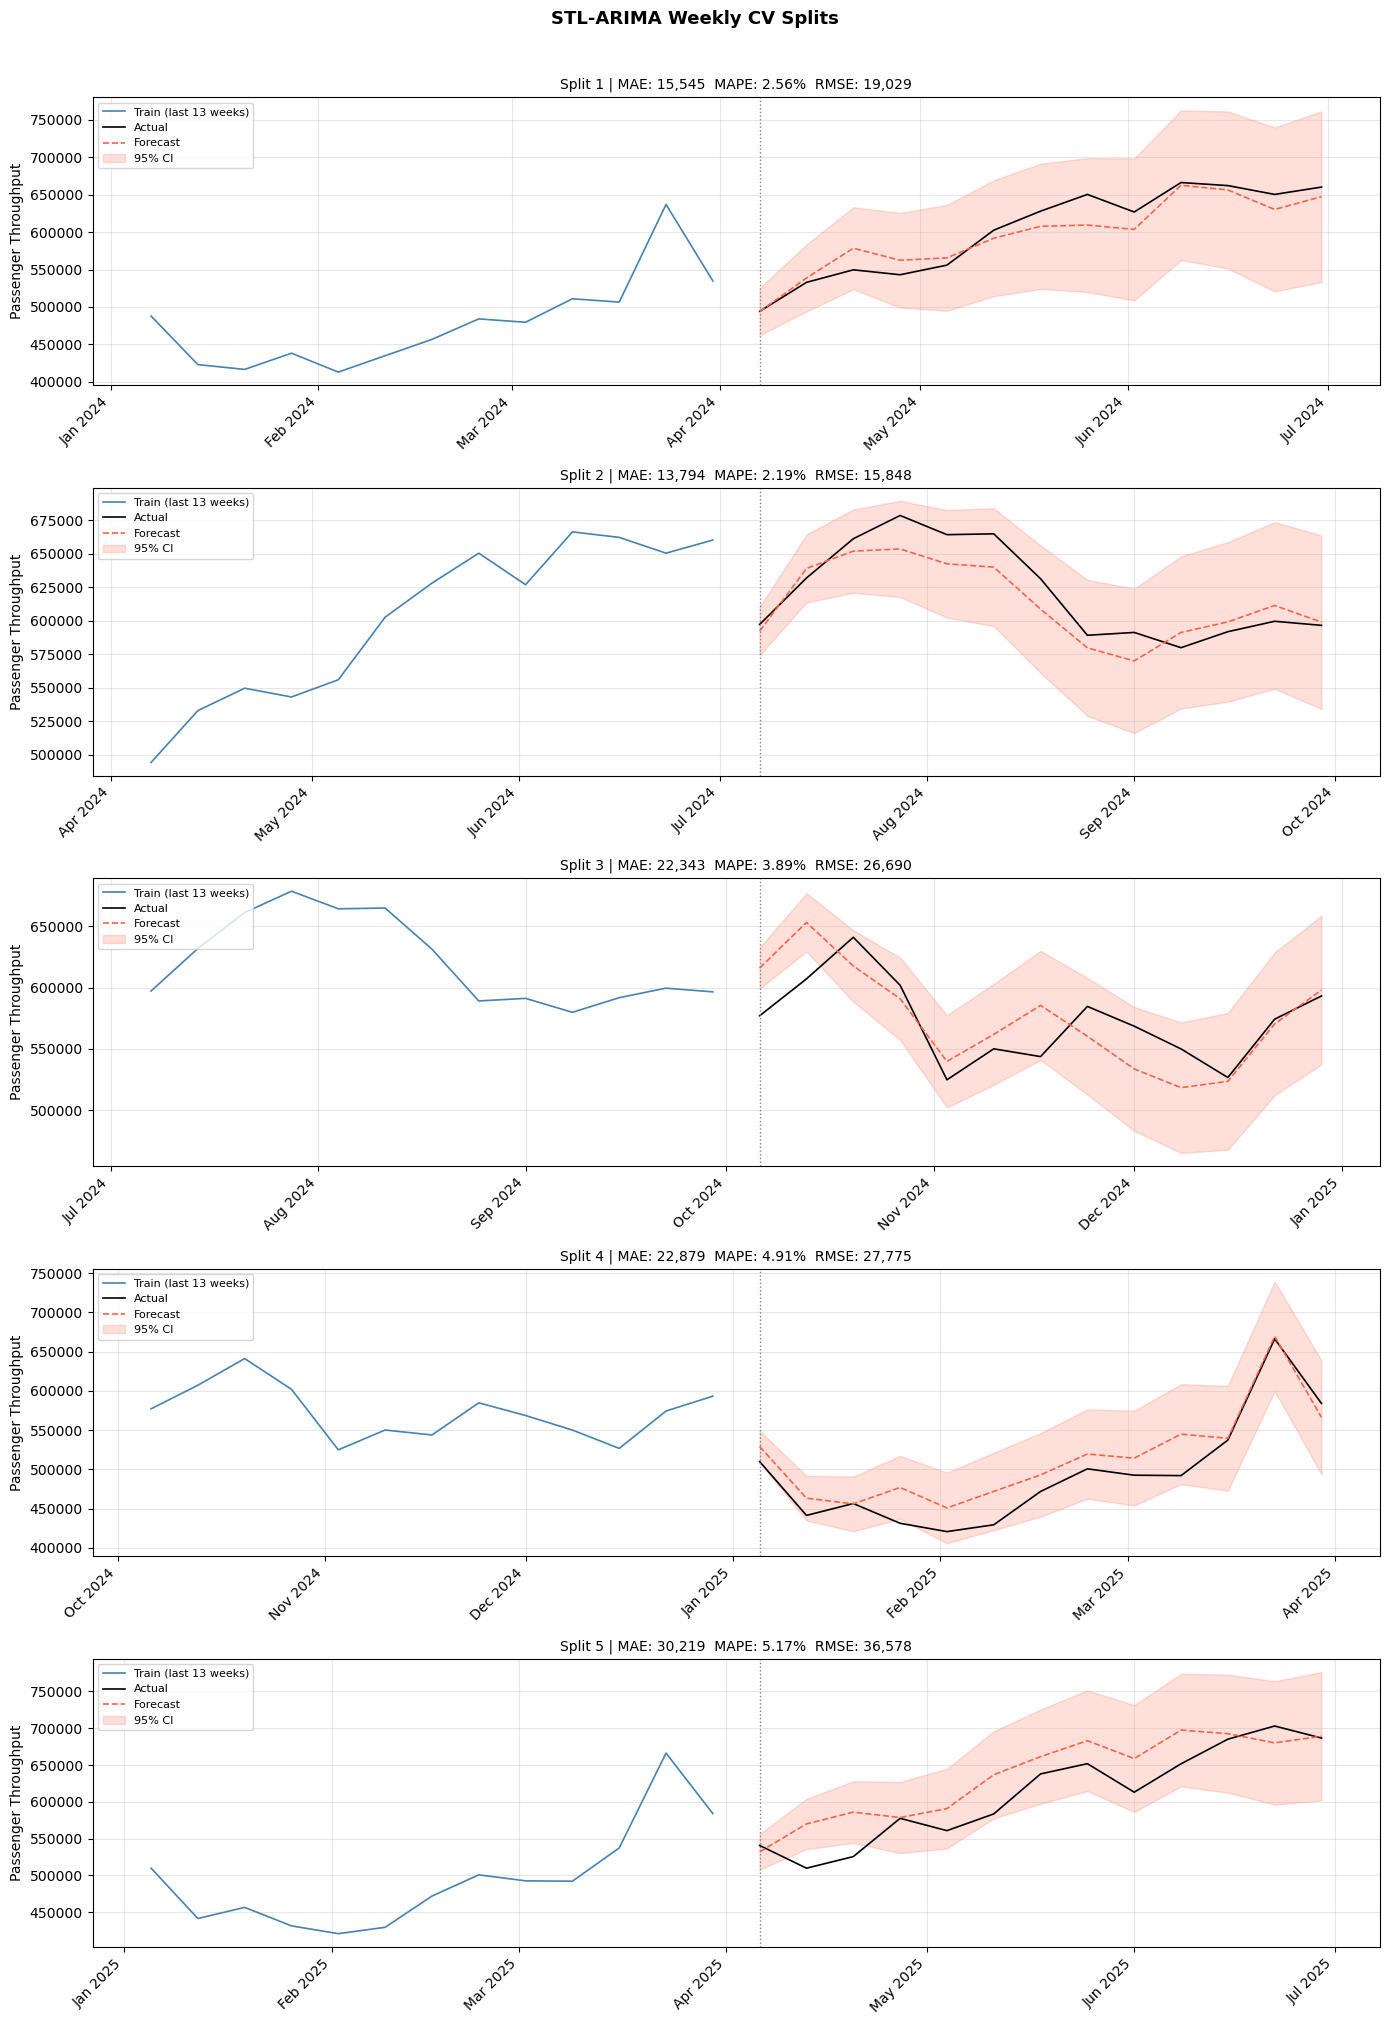

In [42]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(splits_w), 1, figsize=(14, 4 * len(splits_w)))
axes = axes if hasattr(axes, '__len__') else [axes]  # handle single split edge case

for i, (train_idx, test_idx) in enumerate(splits_w):
    ax = axes[i]

    train = ord_weekly.iloc[train_idx]
    test  = ord_weekly.iloc[test_idx]
    n_forecast = len(test_idx)

    model = STLArima(season_length=52, arima_order=(p,d,q), seasonal_order=(P,D,Q,s))
    model.fit(train['total_passenger_throughput'])
    forecasts, lower_bound, upper_bound = model.forecast(n_forecast)

    actuals = test['total_passenger_throughput']
    metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results_stl_w.append(metrics)

    # --- Plotting ---
    train_dates = train.datetime
    test_dates  = test.datetime

    # Plot last N days of training data for context
    context_window = min(13, len(train))
    ax.plot(train_dates.iloc[-context_window:],
            train['total_passenger_throughput'].iloc[-context_window:],
            color='steelblue', label='Train (last 13 weeks)', linewidth=1.2)

    # Actuals in test window
    ax.plot(test_dates, actuals,
            color='black', label='Actual', linewidth=1.2)

    # Forecast
    ax.plot(test_dates, forecasts,
            color='tomato', label='Forecast', linewidth=1.2, linestyle='--')

    # 95% Confidence interval
    ax.fill_between(test_dates, lower_bound, upper_bound,
                    color='tomato', alpha=0.2, label='95% CI')

    # Vertical line separating train/test
    ax.axvline(x=test_dates.iloc[0], color='gray', linestyle=':', linewidth=1)

    ax.set_title(
        f"Split {i+1} | MAE: {metrics['mae']:,.0f}  "
        f"MAPE: {100*metrics['mape']:.2f}%  "
        f"RMSE: {metrics['rmse']:,.0f}",
        fontsize=10
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_ylabel('Passenger Throughput')
    ax.grid(True, alpha=0.3)

plt.suptitle('STL-ARIMA Weekly CV Splits', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Harmonic ARIMA - Weekly

For Harmonic ARIMA, first we must determine the optimal number of frequencies to use in the Harmonic part of the model. We do so by modeling the data using Linear Regression with the Fourier features.


Minimum metrics:
  MAE:  (2, 54,702)
  MAPE: (2, 0.09%)
  RMSE: (24, 60,970)


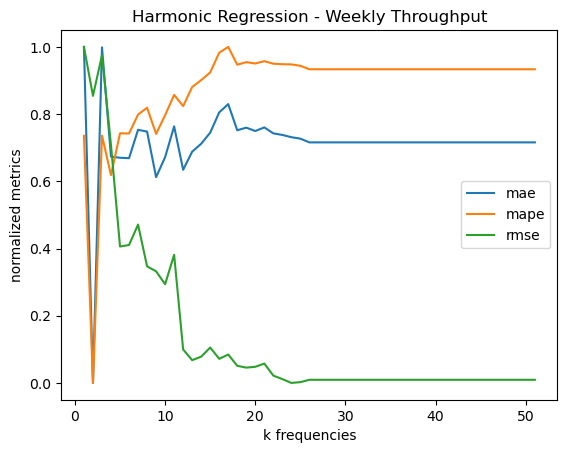

In [49]:
# Average the metrics over all folds for each choice of k_frequency
results = []

for k_freq in range(1, 52):
    # Determine Fourier features for the given number of frequencies
    ord_weekly_X = fourier_features(ord_weekly['week'], m=52, k=k_freq)
    
    k_metrics = []

    for i, (train_idx, test_idx) in enumerate(splits_w, start = 1):
        X_train = ord_weekly_X[train_idx]
        X_test  = ord_weekly_X[test_idx]
        y_train = ord_weekly.iloc[train_idx].total_passenger_throughput
        y_test  = ord_weekly.iloc[test_idx].total_passenger_throughput

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = evaluate_forecast(y_test, y_pred, f"Split {i}")
        metrics['split'] = i
        k_metrics.append(metrics)
    
    metrics_df = pd.DataFrame(k_metrics).set_index('split')
    mean_metrics = {}
    mean_metrics['k_freq'] = k_freq
    mean_metrics['mae']  = metrics_df['mae'].mean()
    mean_metrics['mape'] = metrics_df['mape'].mean()
    mean_metrics['rmse'] = metrics_df['rmse'].mean()
    results.append(mean_metrics)

results_df = pd.DataFrame(results).set_index('k_freq')

print(f"\nMinimum metrics:")
print(f"  MAE:  ({results_df['mae'].idxmin()}, {results_df['mae'].min():,.0f})")
print(f"  MAPE: ({results_df['mape'].idxmin()}, {results_df['mape'].min():.2f}%)")
print(f"  RMSE: ({results_df['rmse'].idxmin()}, {results_df['rmse'].min():,.0f})")

# Normalize all metrics between 0 and 1 for comparison
results_df = (results_df - results_df.min()) / (results_df.max() - results_df.min())
results_df.plot()
plt.title('Harmonic Regression - Weekly Throughput')
plt.xlabel('k frequencies')
plt.ylabel('normalized metrics')
plt.legend()
plt.show()

Unlike with the daily data, this model doesn't appear to attain a minimum in the number of harmonic features to use. Based on the plot above, it appears that the best choice is about k = 25.

We can now apply `autoarima` using the optimal number of Fourier features and the largest set of training data. This will allow us to determine the optimal SARIMA model to use to capture the weekly trend and the errors in the data.

In [50]:
# Create optimal number of Fourier features to model annual trend
ord_weekly_X = fourier_features(ord_weekly['week'], m=52, k=25)
# Take largest split for determining optimal SARIMA model
X_train = ord_weekly_X[splits_w[-1][0]]
X_test  = ord_weekly_X[splits_w[-1][1]]
y_train = ord_weekly.iloc[splits_w[-1][0]].total_passenger_throughput
y_test  = ord_weekly.iloc[splits_w[-1][1]].total_passenger_throughput

arima_model = auto_arima(
    y_train,
    X=X_train,
    seasonal=False,
    d=1, # d = 1 captures linear trend
    stepwise=True,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=3826.251, Time=1.62 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3829.087, Time=0.28 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3831.022, Time=0.42 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3834.154, Time=0.56 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=4521.596, Time=0.27 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=3837.616, Time=0.85 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=3836.838, Time=0.72 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=3830.669, Time=1.59 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=3836.933, Time=1.97 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3837.791, Time=0.76 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=3841.723, Time=1.48 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=3832.799, Time=1.25 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=3.01 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=inf, Time=2.46 sec

Best model:  ARIMA(2,1,2)(0,0,0)[0] interc

After running the `autoarima`, we find that the optimal ARIMA model is `ARIMA(2,1,2)(0,0,0)[0]` with intercept.

Finally, we can apply this model across all the splits and see what metrics we obtain.

In [51]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

results_harm_arima_w = []

for i, (train_idx, test_idx) in enumerate(splits_w, start=1):
        train = ord_weekly.iloc[train_idx]
        test  = ord_weekly.iloc[test_idx]

        model = HarmonicARIMA(harmonic_m=52,
                              harmonic_k=25,
                              arima_order=(2,1,2), 
                              seasonal_order=(0,0,0,0),
                              with_intercept=True)
        model.fit(train.week, train.total_passenger_throughput)
        forecasts, lower_bound, upper_bound = model.forecast(test.week)

        metrics = evaluate_forecast(test.total_passenger_throughput, forecasts, model_name=f"Split {i}")
        metrics['split'] = i
        results_harm_arima_w.append(metrics)
        print(f"Split {i} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")
        
results_harm_arima_w_df = pd.DataFrame(results_harm_arima_w).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_harm_arima_w_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_harm_arima_w_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_harm_arima_w_df['rmse'].mean():,.0f}")

Split 1 - MAE: 18448, MAPE: 2.95%, RMSE: 22461
Split 2 - MAE: 19708, MAPE: 3.26%, RMSE: 23615
Split 3 - MAE: 23174, MAPE: 4.06%, RMSE: 26244
Split 4 - MAE: 32139, MAPE: 6.74%, RMSE: 39166
Split 5 - MAE: 29059, MAPE: 5.03%, RMSE: 36518

CV Average:
  MAE:  24,506
  MAPE: 4.41%
  RMSE: 29,601


Based on these metrics, this model doesn't appear to perform as well as the STL ARIMA model. It also doesn't beat one of the baselines.

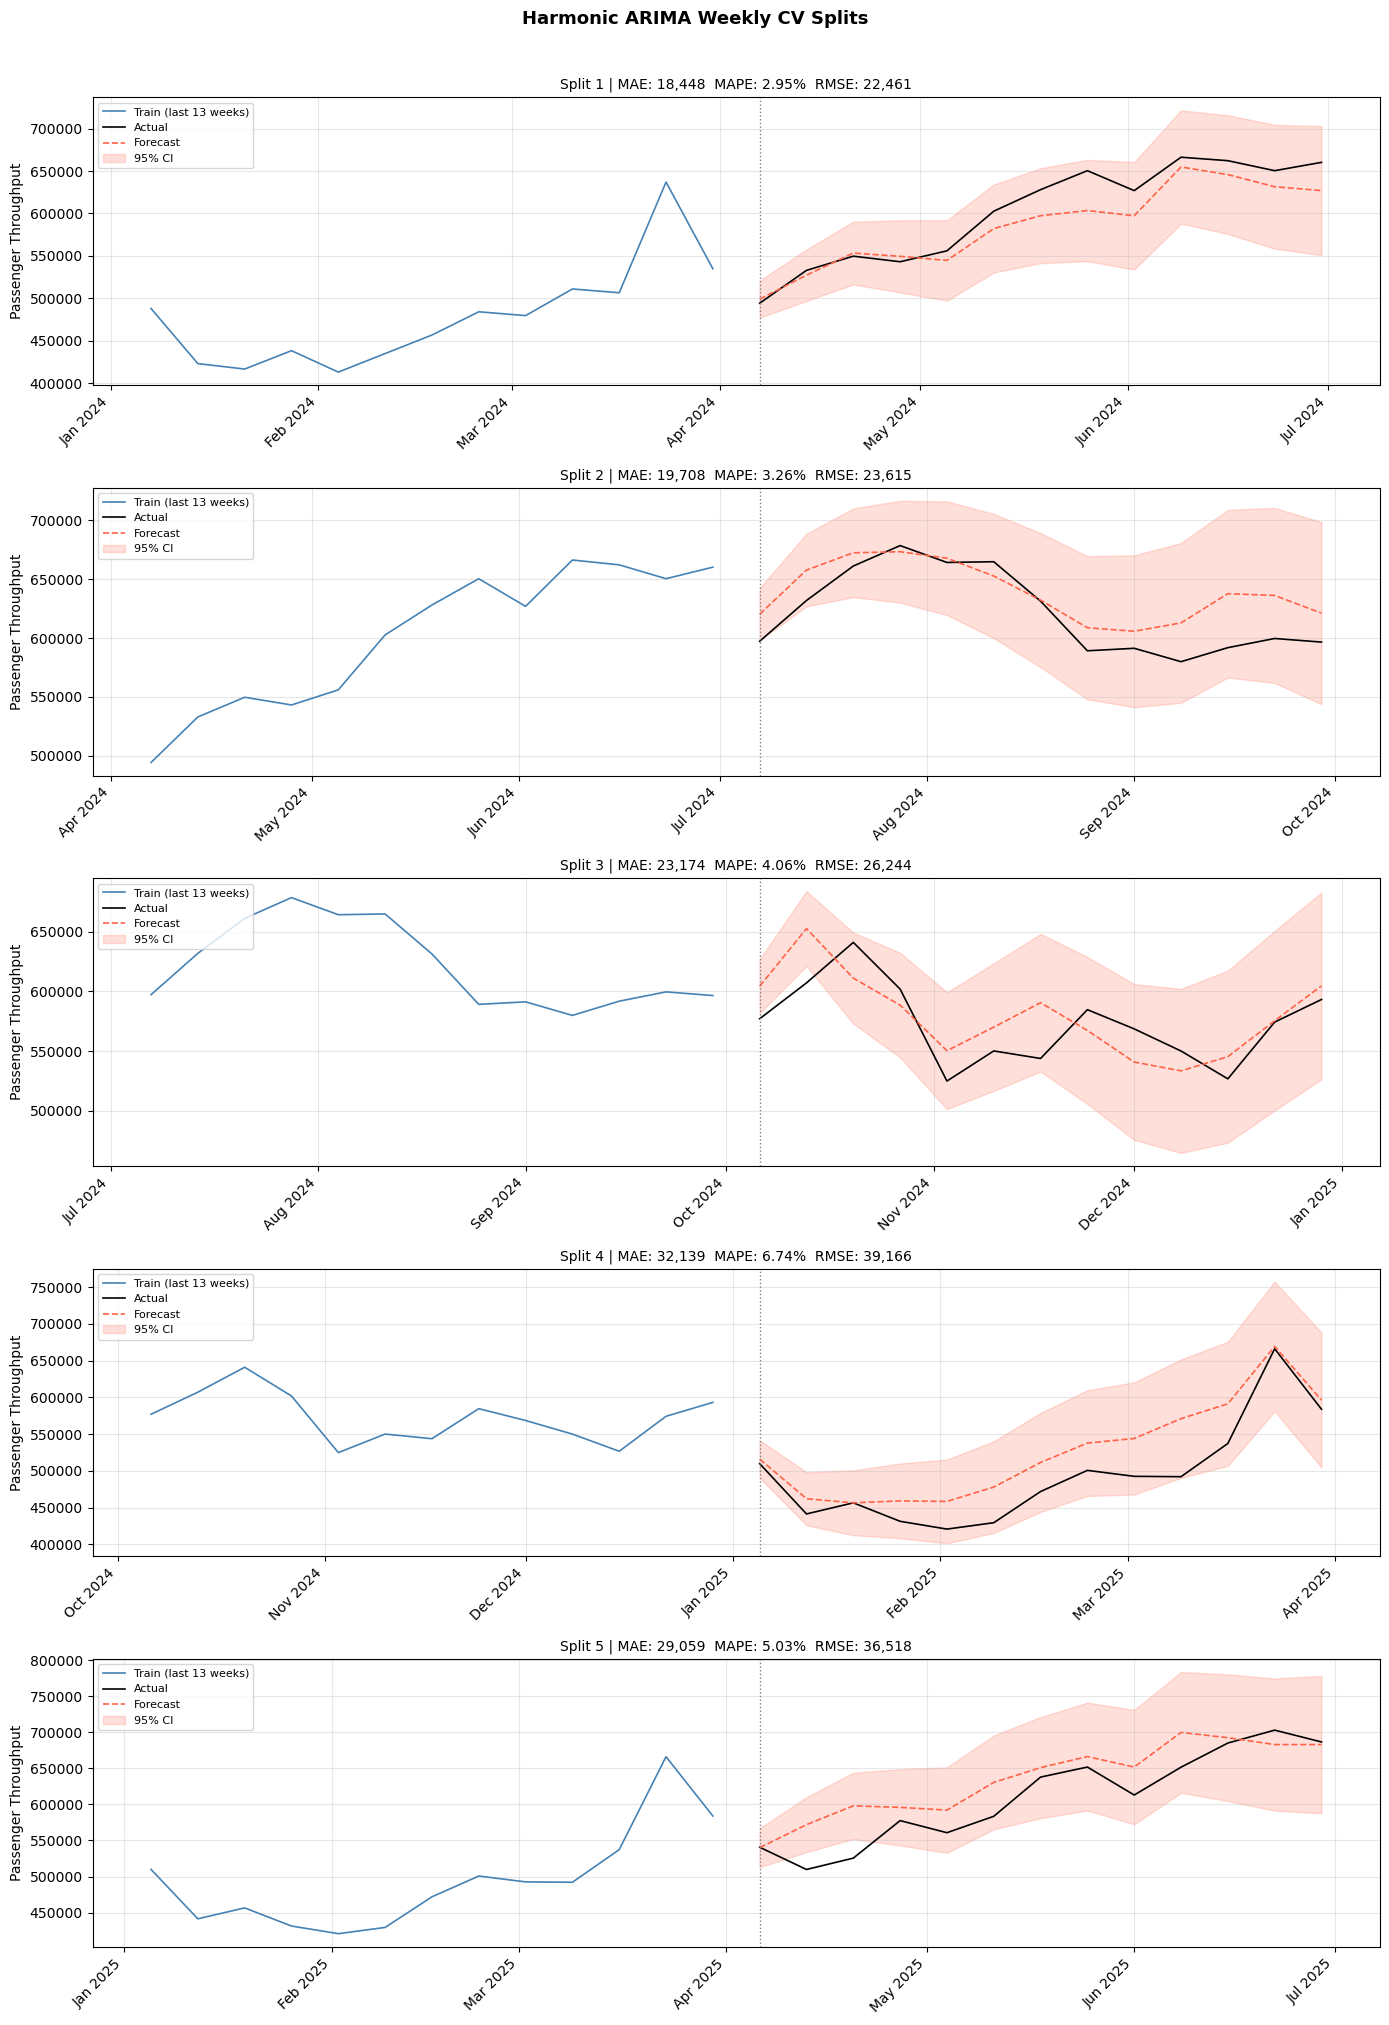

In [52]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(splits_w), 1, figsize=(14, 4 * len(splits_w)))
axes = axes if hasattr(axes, '__len__') else [axes]  # handle single split edge case

for i, (train_idx, test_idx) in enumerate(splits_w):
    ax = axes[i]

    train = ord_weekly.iloc[train_idx]
    test  = ord_weekly.iloc[test_idx]

    model = HarmonicARIMA(harmonic_m=52,
                          harmonic_k=25,
                          arima_order=(2,1,2), 
                          seasonal_order=(0,0,0,0),
                          with_intercept=True)
    model.fit(train.week, train.total_passenger_throughput)
    forecasts, lower_bound, upper_bound = model.forecast(test.week)

    actuals = test.total_passenger_throughput
    metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")

    # --- Plotting ---
    train_dates = train.datetime
    test_dates  = test.datetime

    # Plot last N days of training data for context
    context_window = min(13, len(train))
    ax.plot(train_dates.iloc[-context_window:],
            train['total_passenger_throughput'].iloc[-context_window:],
            color='steelblue', label='Train (last 13 weeks)', linewidth=1.2)

    # Actuals in test window
    ax.plot(test_dates, actuals,
            color='black', label='Actual', linewidth=1.2)

    # Forecast
    ax.plot(test_dates, forecasts,
            color='tomato', label='Forecast', linewidth=1.2, linestyle='--')

    # 95% Confidence interval
    ax.fill_between(test_dates, lower_bound, upper_bound,
                    color='tomato', alpha=0.2, label='95% CI')

    # Vertical line separating train/test
    ax.axvline(x=test_dates.iloc[0], color='gray', linestyle=':', linewidth=1)

    ax.set_title(
        f"Split {i+1} | MAE: {metrics['mae']:,.0f}  "
        f"MAPE: {100*metrics['mape']:.2f}%  "
        f"RMSE: {metrics['rmse']:,.0f}",
        fontsize=10
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_ylabel('Passenger Throughput')
    ax.grid(True, alpha=0.3)

plt.suptitle('Harmonic ARIMA Weekly CV Splits', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()